In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta, date
#import time
import matplotlib.pyplot as plt

import warnings

import utils

from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage
from pypfopt.efficient_frontier import EfficientFrontier

In [2]:
df_portofolio, df_quotes, _, _ = utils.load_data()
df_quotes = df_quotes.bfill()
code2name_dict = df_portofolio['Nome'].to_dict()

In [3]:
def get_quote_date(days_ago: int):
    return df_quotes.index[df_quotes.index <= (df_quotes.index[0]-pd.Timedelta(days=days_ago))].max()

def oscilator(ts, period=21, smooth_k=3):
    # Calculate the highest high and lowest low over the specified period
    data = ts.sort_index()[-period-smooth_k:]
    highest_high = data.rolling(window=period).max()
    lowest_low = data.rolling(window=period).min()
    
    # Calculate %K
    percent_k = ((data - lowest_low) / (highest_high - lowest_low)) * 100
    
    # Smooth %K using a moving average
    smooth_k_line = percent_k.rolling(window=smooth_k).mean()
    return smooth_k_line.iloc[-2:]

div_f = 365 / 53
def get_kpis(days_ago: int = 365 //div_f, base_return: float=0.03):
    days_ago_std = 365 // 2
    start_date = get_quote_date(days_ago=days_ago)
    start_date_std = get_quote_date(days_ago=days_ago_std)
    df_features = pd.DataFrame(index=df_quotes.columns)
    #df_features['Name'] = df_features.apply(lambda x: code2name_dict.get(x.name,x.name),axis=1)
    df_features['Growth'] = df_quotes.apply(lambda x: (x.iloc[0]/x.loc[start_date])**(div_f)-1)
    df_features['STD'] = df_quotes.loc[:start_date_std].apply(lambda x: x/x.shift(-1), axis=0).std(axis=0)
    df_features['Racio'] = (df_features['Growth']-base_return)/df_features['STD']
    ds = df_quotes.loc[:start_date].apply(lambda x: x/x.shift(-1)-1, axis=0).clip(upper=0)**2
    df_features['D_Volat'] = np.sqrt(ds.mean())
    df_features['Racio2'] = (df_features['Growth']-base_return)*2/(df_features['STD'] + df_features['D_Volat']*2)
    ts_min, ts_max, ts_last = df_quotes.min(), df_quotes.max(), df_quotes.iloc[0,:]
    df_features['PricePosition'] = (ts_last-ts_min)/(ts_max-ts_min)
    osc_df = df_quotes.apply(lambda x: oscilator(x), axis=0)
    df_features['Oversold Exit'] = osc_df.apply(lambda x: (x.iloc[1]>20) & (x.iloc[0]<20))
    df_features['Overbought Entry'] = osc_df.apply(lambda x: (x.iloc[1]>80) & (x.iloc[0]<80))
    return df_features[df_features['STD']>0].sort_values(by='Racio',ascending=False)

df_features = get_kpis()
last_quotes = df_quotes.iloc[0]
df_features['Amount EUR'] = last_quotes * df_portofolio['Quantidade']

In [4]:
def change_trend(ts: pd.Series, long_window: int=30, short_window:int=10, kpi_window:int=130, lag:int=1):
    ts = ts.sort_index()
    short_ma = ts.ewm(span=short_window, adjust=False).mean()
    short_ma.name = 'short_ma'
    long_ma = ts.ewm(span=long_window, adjust=False).mean()
    long_ma.name ='long_ma'
    if short_ma.iloc[-1-lag] < long_ma.iloc[-1-lag] and short_ma.iloc[-1] > long_ma.iloc[-1]:
        # Short-term MA crosses above long-term MA: Upward trend
        status = "Up"
    elif short_ma.iloc[-1-lag] > long_ma.iloc[-1-lag] and short_ma.iloc[-1] < long_ma.iloc[-1]:
        # Short-term MA crosses below long-term MA: Downward trend
        status = "Down"
    else:
        # No recent trend change
       status = "NaN"
    sma_growth = short_ma.iloc[-1] / short_ma.iloc[-1-short_window]
    ts_min, ts_max = ts.iloc[-kpi_window:].min(), ts.iloc[-kpi_window:].max()
    price_position = (ts.iloc[-1]-ts_min)/(ts_max-ts_min)
    return status, short_ma, long_ma, sma_growth, price_position

def volatility(returns: pd.Series):
    return np.sqrt((returns**2).mean())

def print_fund_change(symb: str):
    _, sma, lma,_,_ = change_trend(df_quotes[symb])
    df_tmp = pd.concat([df_quotes[symb],sma,lma],axis=1)
    title = code2name_dict.get(symb,'')
    df_tmp.iloc[:130].plot(title=title,figsize=(12,4))
    plt.show()
    #returns = df_quotes[symb].pct_change().dropna()
    #avg_returns = returns.mean()
    #print(f"Downside Volatiliy:{volatility(returns.clip(upper=avg_returns))}. Upside Volatiliy:{volatility(returns.clip(lower=avg_returns))}.")

def plot_stochastic_oscillator(symb: str, period=14, smooth_k=3, smooth_d=3):
    """
    Calculate and plot the Stochastic Oscillator for an asset.
    
    Parameters:
        symb (str): The symbol to use.
        period (int): The lookback period for calculating the Stochastic Oscillator. Default is 14.
        smooth_k (int): The smoothing period for %K. Default is 3.
        smooth_d (int): The smoothing period for %D (signal line). Default is 3.
    """
    # Ensure the symbol is valid
    if symb not in df_quotes.columns:
        raise ValueError(f"The symbol '{symb}' does not exist in the data.")
    
    data = df_quotes[symb].sort_index()
    
    # Calculate the highest high and lowest low over the specified period
    highest_high = data.rolling(window=period).max()
    lowest_low = data.rolling(window=period).min()
    
    # Calculate %K
    percent_k = ((data - lowest_low) / (highest_high - lowest_low)) * 100
    
    # Smooth %K using a moving average
    smooth_k_line = percent_k.rolling(window=smooth_k).mean()
    
    # Calculate %D (signal line) as a moving average of %K
    percent_d = smooth_k_line.rolling(window=smooth_d).mean()
    
    # Plot the Stochastic Oscillator
    plt.figure(figsize=(12, 2))
    plt.plot(smooth_k_line.iloc[-130:], label=f"%K (Fast Line, {smooth_k}-period)", color='lightblue')
    #plt.plot(percent_d, label=f"%D (Signal Line, {smooth_d}-period)", color='orange')
    plt.axhline(80, color='red', linestyle='--', label='Overbought (80)')
    plt.axhline(20, color='green', linestyle='--', label='Oversold (20)')
    #plt.title(f"{code2name_dict.get(symb,'')} Stochastic Oscillator")
    #plt.xlabel("Date")
    #plt.ylabel("Oscillator Value")
    #plt.legend()
    #plt.grid()
    plt.show()

def buy_opps_change_trend(lag:int=1,growth_treshold:int=1.0005, relative_price_treshold:int=1.5, graph=True):
    print("####################  BUY OPPS  #####################")
    df_change_opp = pd.DataFrame(
        [(symb,g,pp) for x,_,_,g,pp,symb in [change_trend(ts=df_quotes[symb],lag=lag)+(symb,) for symb in df_quotes.columns] if x == 'Up'],
        columns=['symb','growth','relative_price']
        ).sort_values(by='relative_price')
    df_change_opp = df_change_opp[(df_change_opp['growth']>growth_treshold) & (df_change_opp['relative_price']<relative_price_treshold)]
    if graph:
        for symb in df_change_opp['symb']:
            print_fund_change(symb)
    return df_change_opp['symb']

def sell_opps(lag:int=1):
    print("####################  SELL OPPS  #####################")
    df_change_opp = pd.DataFrame(
        [(symb,g,pp) for x,_,_,g,pp,symb in [change_trend(df_quotes[symb], lag=lag)+(symb,) for symb in df_portofolio.index] if x == 'Down'],
        columns=['symb','growth','relative_price']
        ).sort_values(by='relative_price')
    for symb in df_change_opp['symb']:
        print_fund_change(symb)
    return df_change_opp['symb']

def portofolio_trend(fund_list=df_portofolio.index):
    print("####################  PORTOFOLIO TRENDS  #####################")
    for symb in fund_list:
        print_fund_change(symb)


### Evaluate Portofolio

In [5]:
df_plot = df_features.loc[df_portofolio.index].sort_values(by='Racio2',ascending=False)
df_plot['Name'] = df_plot.apply(lambda x: code2name_dict.get(x.name,''),axis=1)
df_plot.sort_values(by=['Racio2'],ascending=False).to_csv('portfolio_tmp_2.csv')
df_plot

,Growth,STD,Racio,D_Volat,Racio2,PricePosition,Oversold Exit,Overbought Entry,Amount EUR,Name
Code,,,,,,,,,,
SGLD.AS,3.996890,0.009970,397.880164,0.001989,568.820214,0.994530,False,False,47428.200989,Invesco Physical Gold ETC
URA,6.711829,0.026623,250.980258,0.014440,240.776399,0.867117,False,False,18287.462871,Global X Uranium
GOOGL,2.755017,0.019057,142.993352,0.006429,170.769867,1.000000,False,True,38015.264458,Alphabet Inc Class A
IBM,1.961161,0.017224,112.119246,0.008979,109.777596,0.918381,False,False,19539.283883,International Business Machines
QTUM,1.966337,0.015676,123.519093,0.010715,104.367021,0.951578,False,False,49054.720000,Defiance Quantum
LU0524465977,0.291963,0.007199,36.389859,0.005059,30.254058,0.958530,False,False,43443.214336,Alken European Opport A
IWDA.AS,0.188395,0.007728,20.496625,0.004545,18.835658,0.934551,False,False,19703.609665,iShares Core MSCI World UCITS
IGF,0.141387,0.007201,15.467720,0.003845,14.959593,0.983724,False,False,19153.981723,iShares Global Infrastructure
VSS,0.131587,0.007032,14.446069,0.004657,12.429076,0.946739,False,False,17068.298680,Vanguard FTSE All-World ex-US


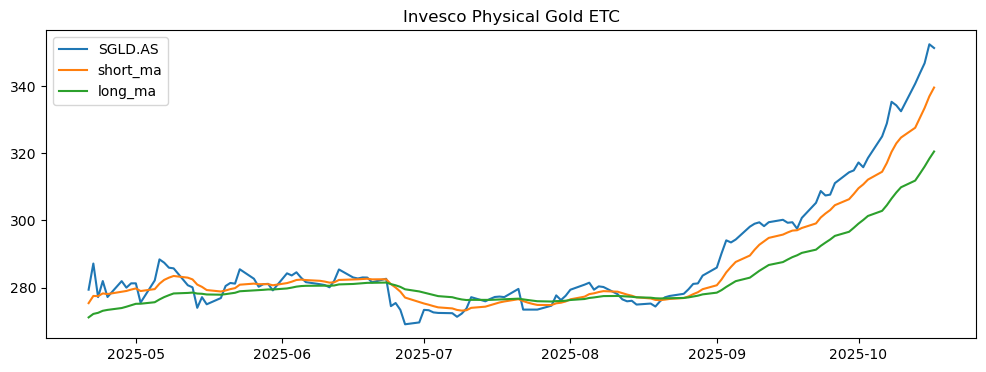

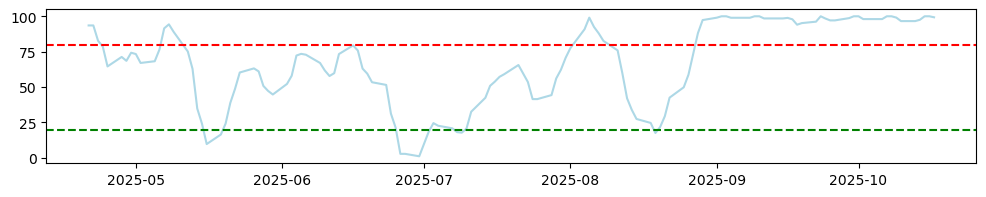

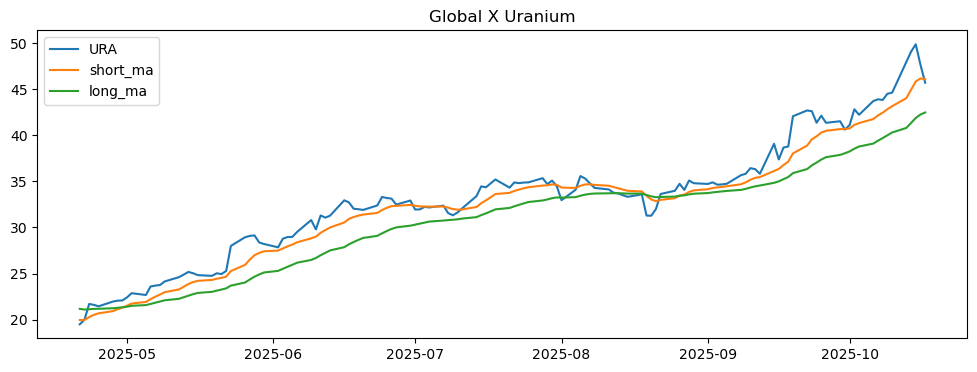

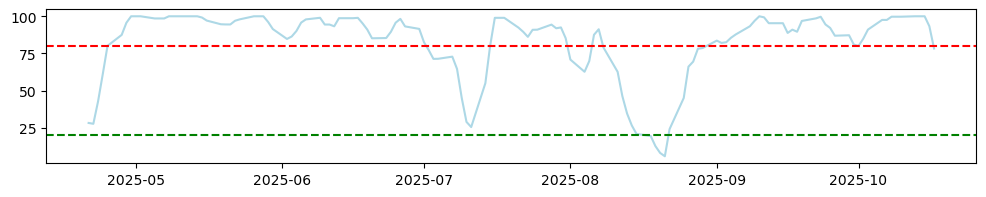

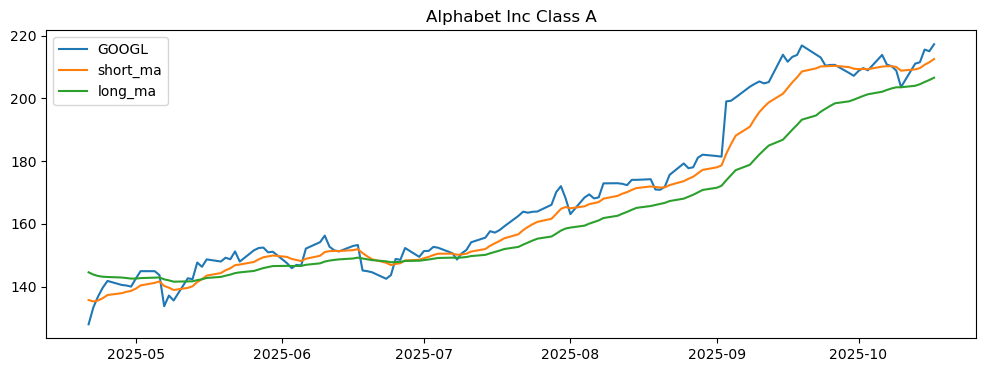

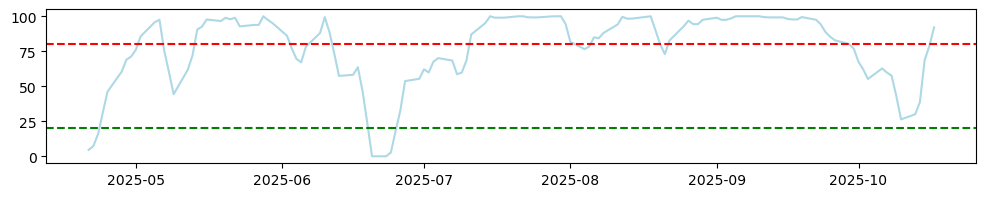

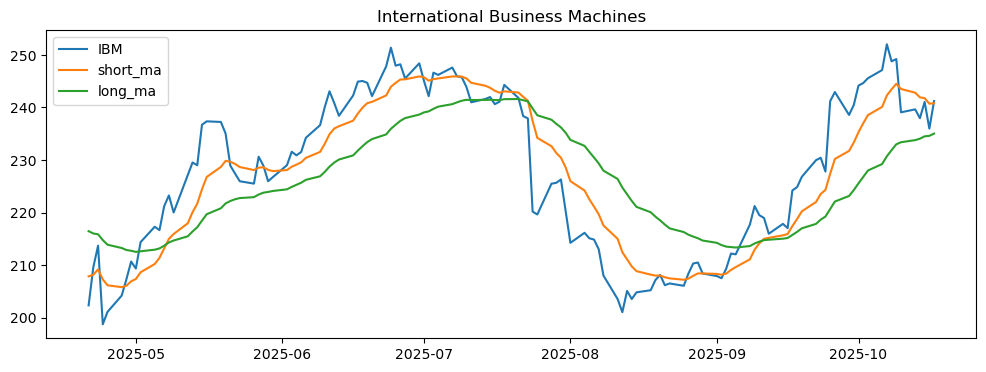

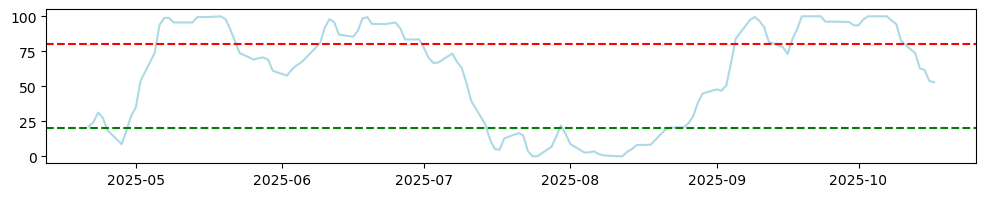

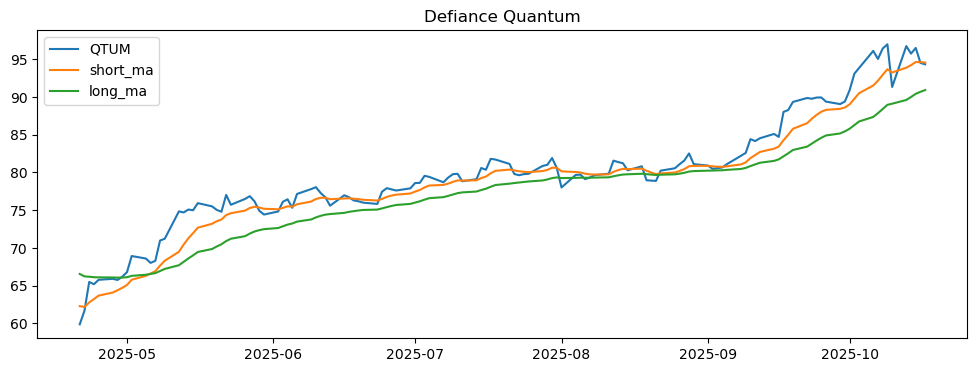

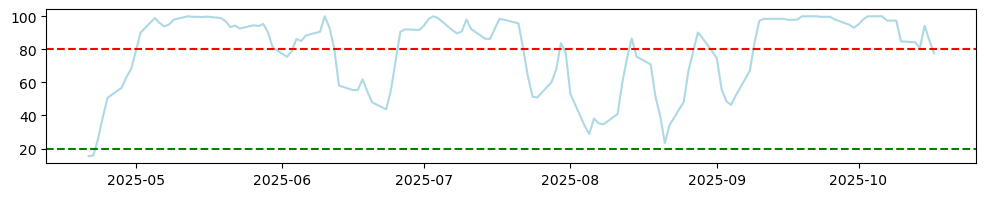

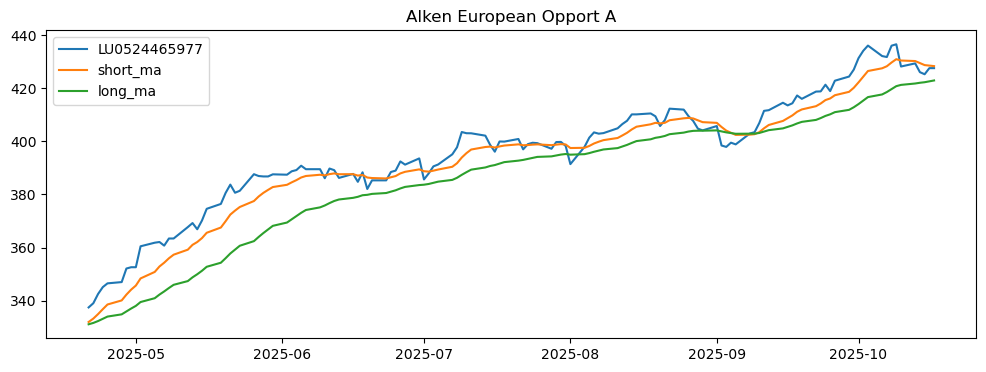

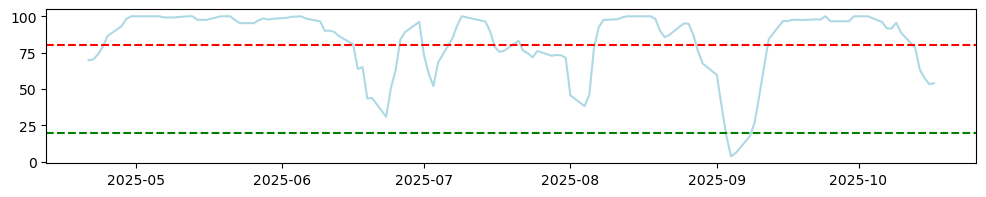

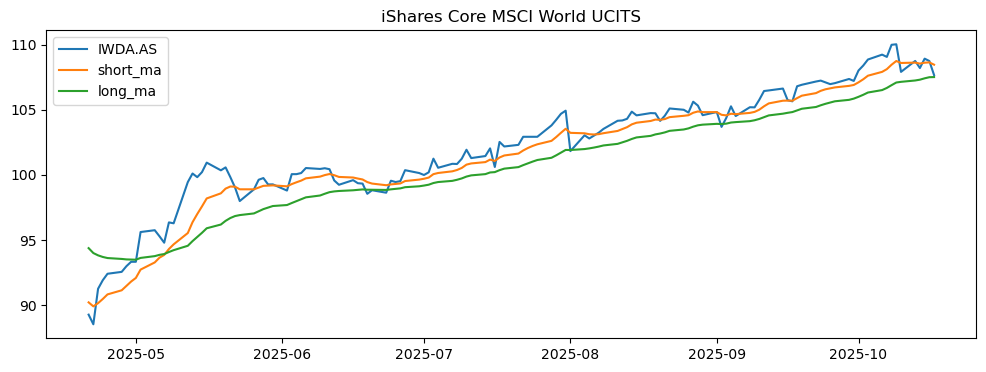

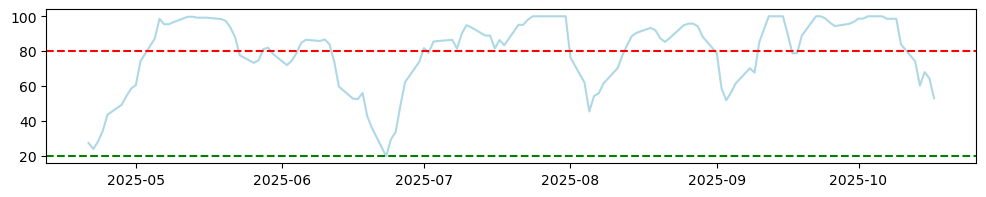

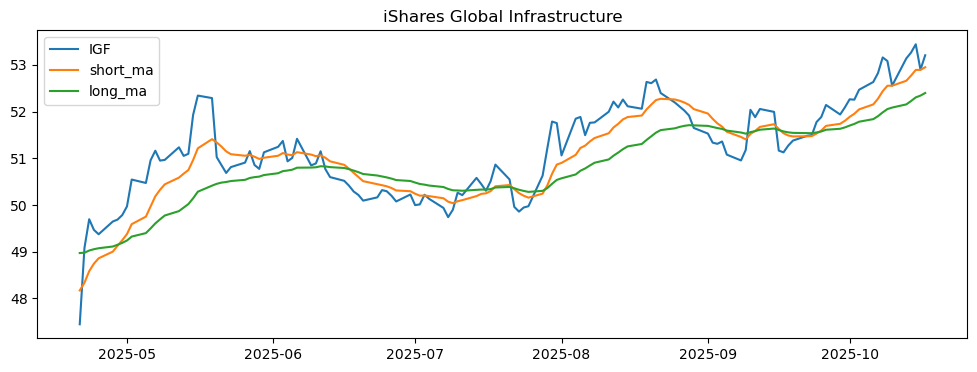

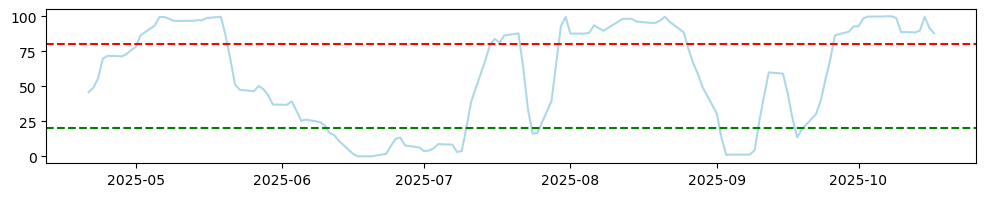

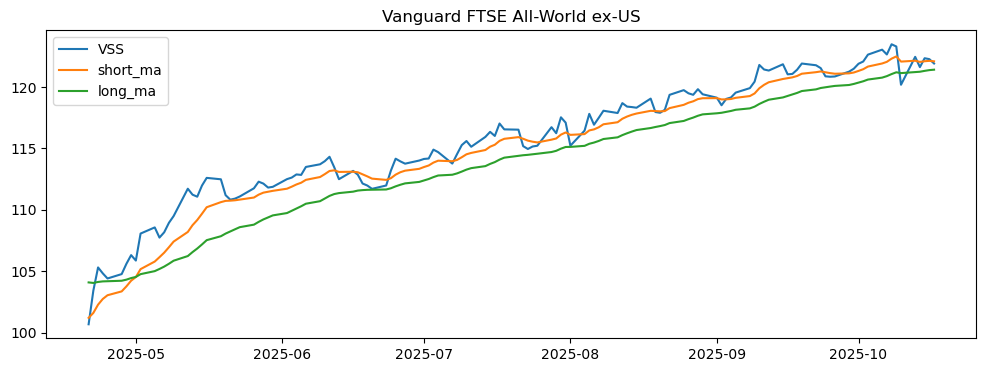

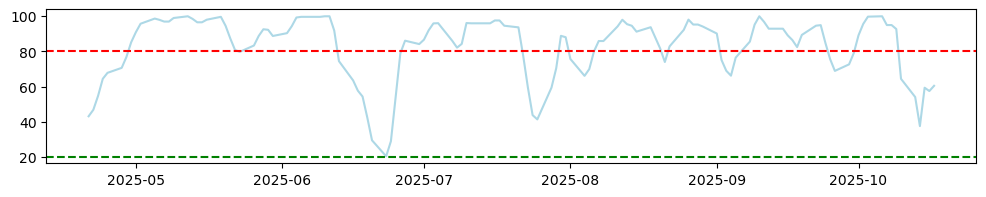

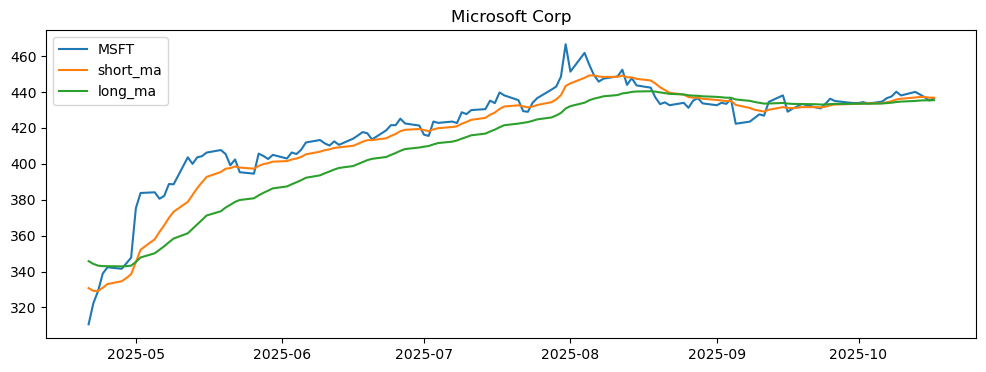

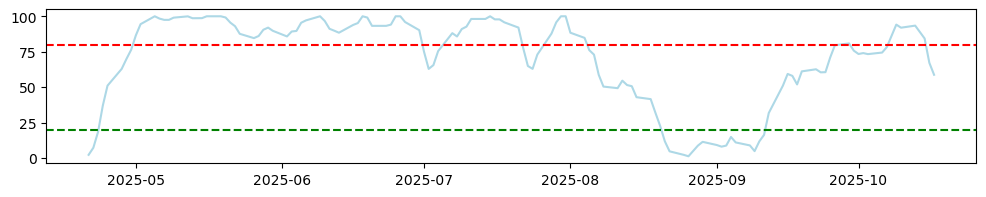

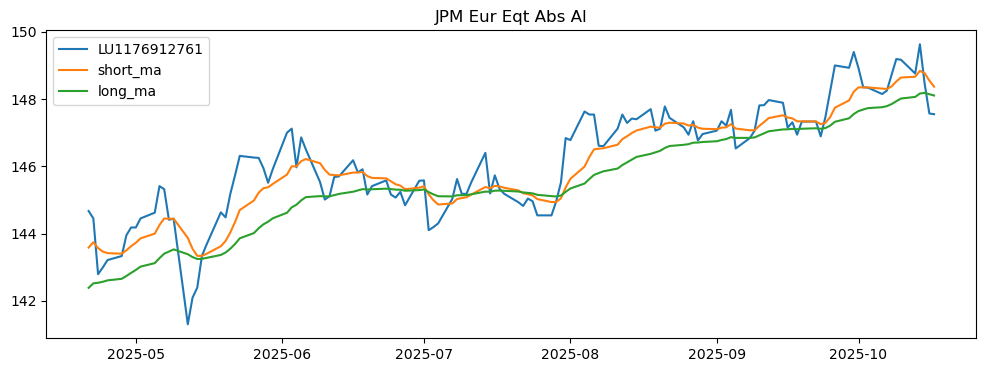

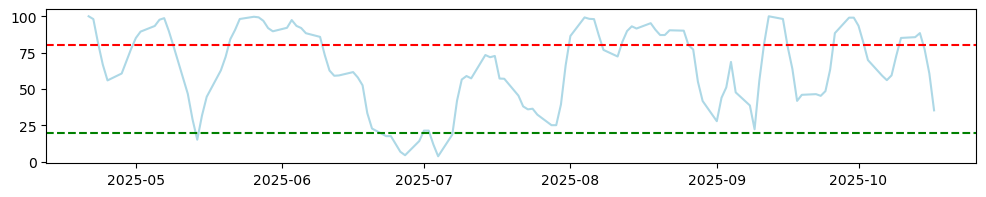

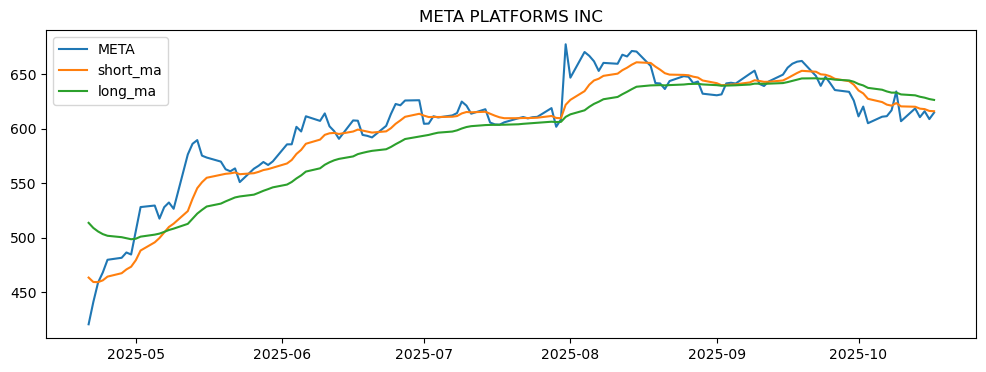

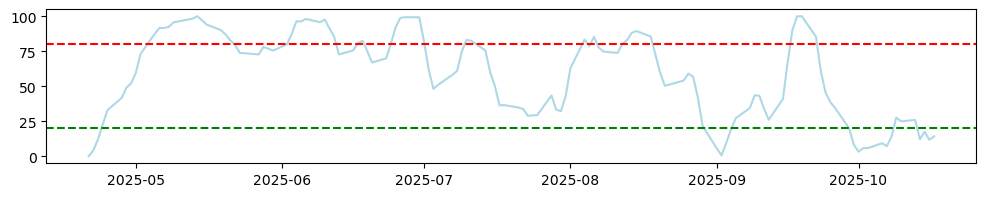

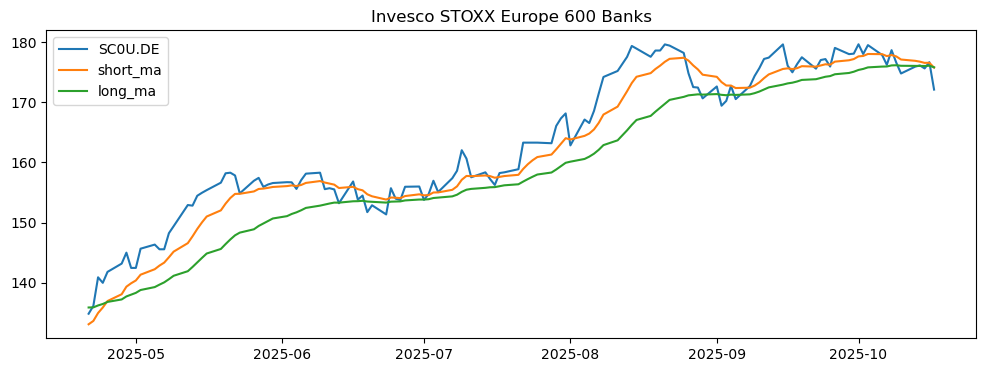

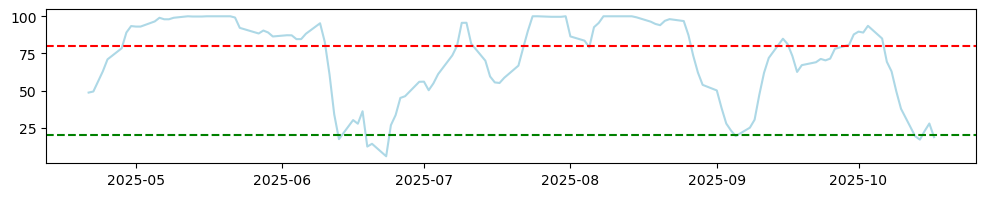

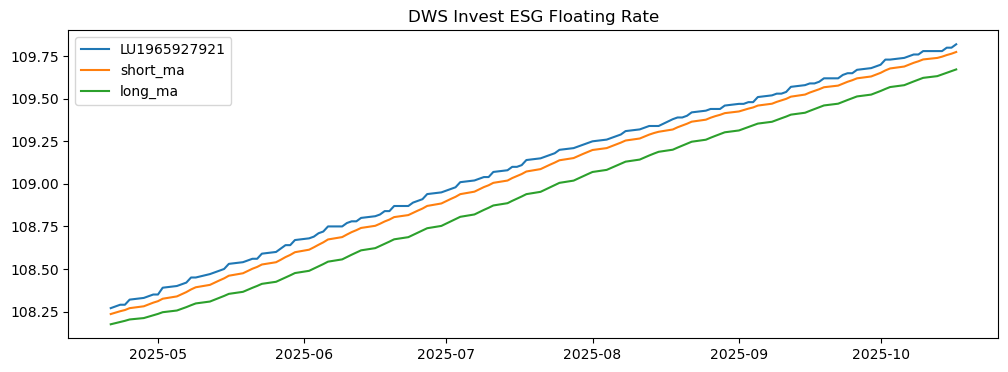

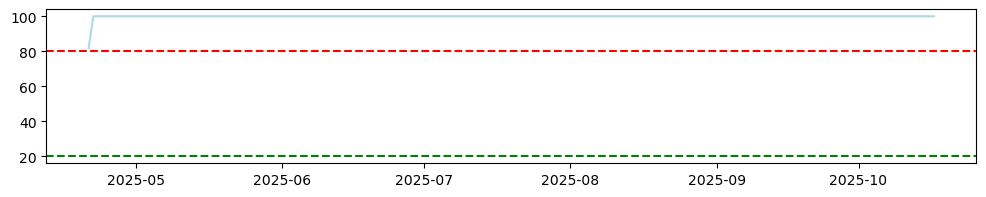

In [6]:

for symb in df_plot.index:
    print_fund_change(symb)
    plot_stochastic_oscillator(symb, period=21, smooth_k=3, smooth_d=3)

####################  SELL OPPS  #####################


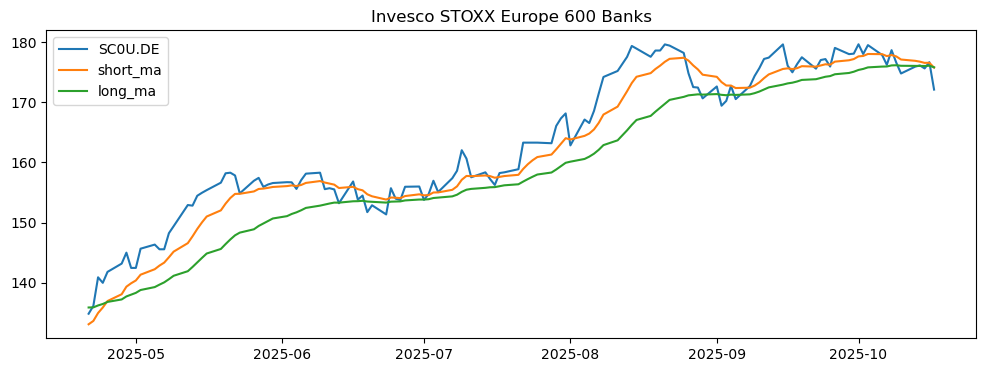

0    SC0U.DE
Name: symb, dtype: object

In [7]:
sell_opps(lag=5)


### Buy Opportunities

In [8]:
df_plot = df_features[df_features['Overbought Entry']].sort_values(by='PricePosition',ascending=False)[:15]
df_plot

,Growth,STD,Racio,D_Volat,Racio2,PricePosition,Oversold Exit,Overbought Entry,Amount EUR
GOOGL,2.755017,0.019057,142.993352,0.006429,170.769867,1.0,False,True,38015.264458
IE00B3MXRR34,0.126078,0.004602,20.876729,0.002749,19.024245,1.0,False,True,NaN
LU0317020898,0.187100,0.006961,22.569741,0.004781,19.017152,1.0,False,True,NaN
IE00BD5CTX77,0.000000,0.003138,-9.560173,0.001291,-10.488171,1.0,False,True,NaN
LU0217723054,0.181934,0.002258,67.283318,0.001223,64.582483,1.0,False,True,NaN
LU1062842882,0.177485,0.002487,59.298223,0.001460,54.545726,1.0,False,True,NaN
LU0562246966,0.125655,0.001631,58.642011,0.000610,67.081293,1.0,False,True,NaN
LU1514167995,0.054150,0.001360,17.759124,0.000695,17.558266,1.0,False,True,NaN
LU0806867908,0.213959,0.002500,73.575491,0.001023,80.922079,1.0,False,True,NaN
LU1523963418,0.073514,0.001681,25.883039,0.000614,29.915187,1.0,False,True,NaN


GOOGL Alphabet Inc Class A


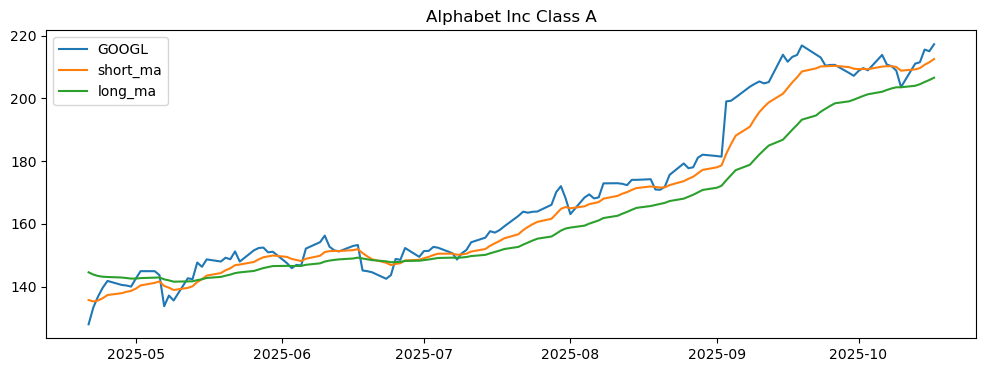

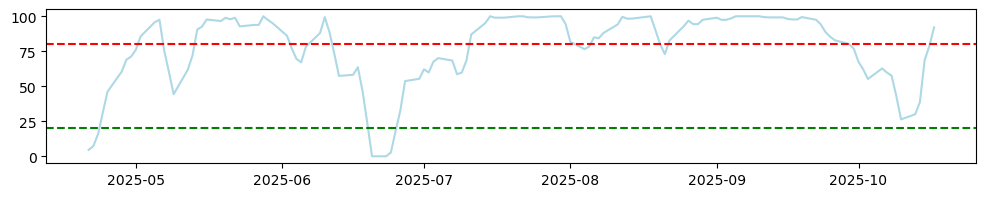

IE00B3MXRR34 


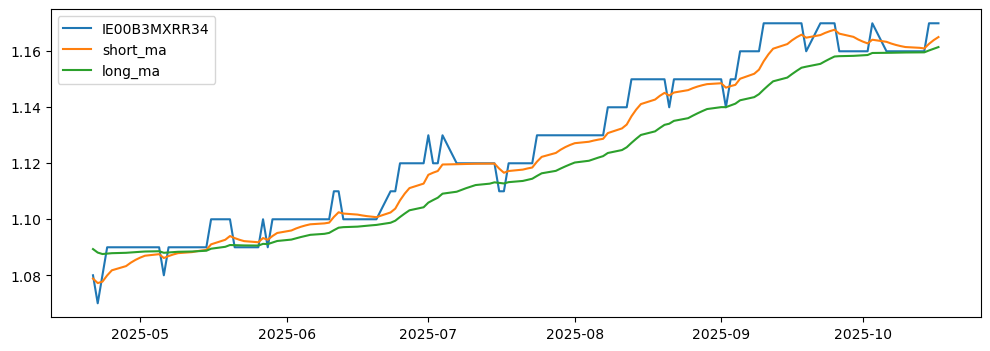

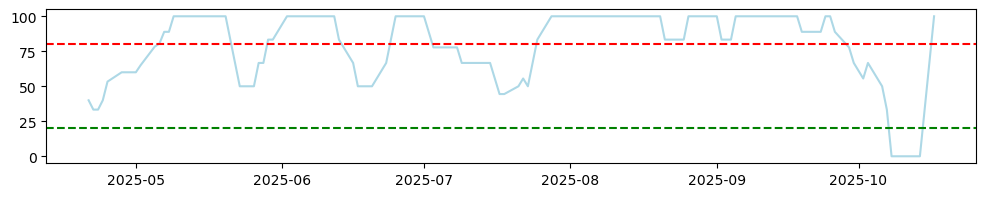

LU0317020898 


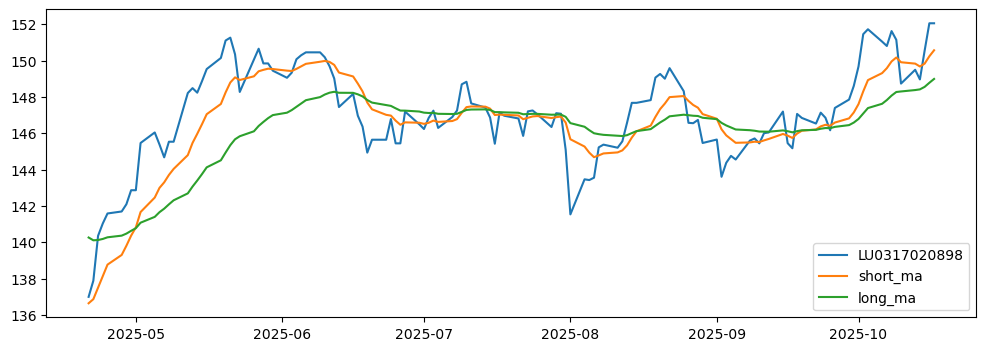

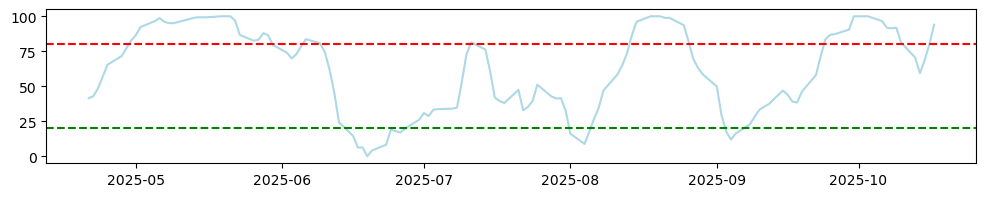

IE00BD5CTX77 


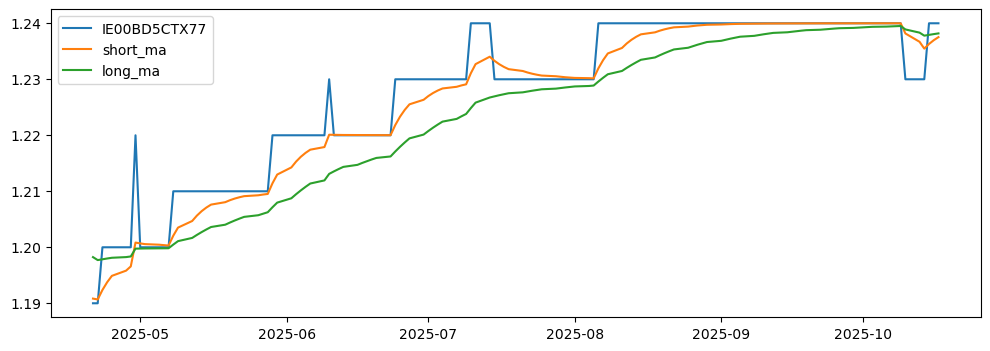

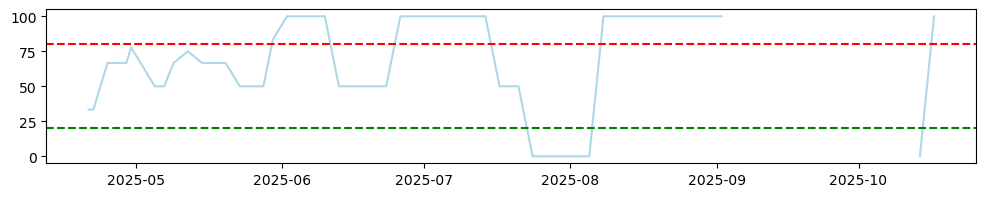

LU0217723054 


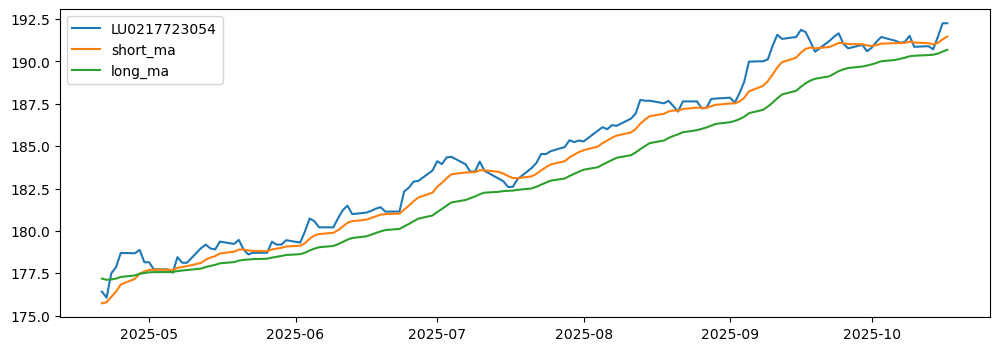

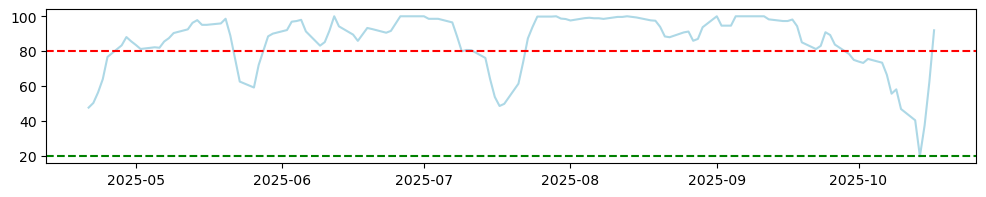

LU1062842882 


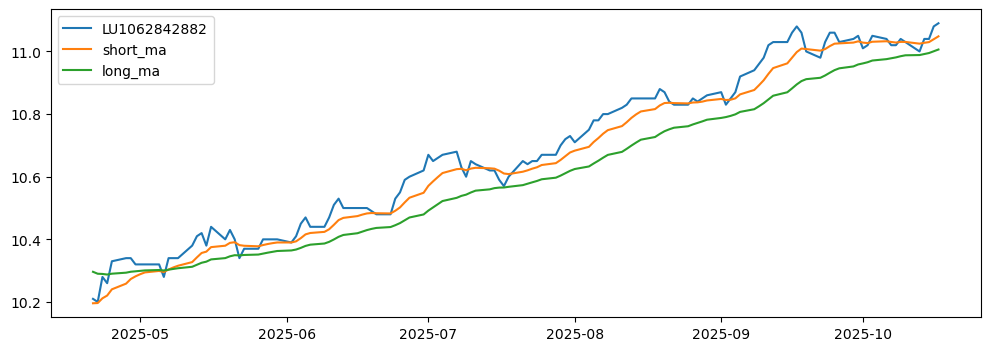

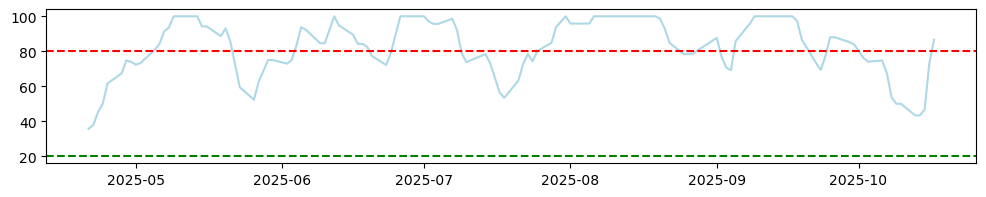

LU0562246966 


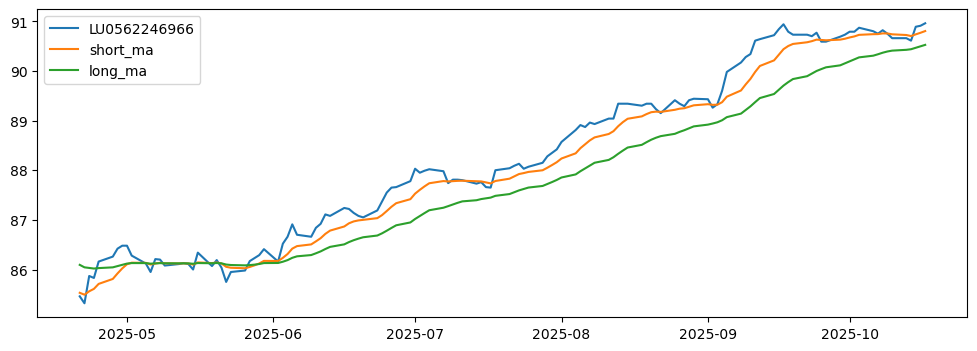

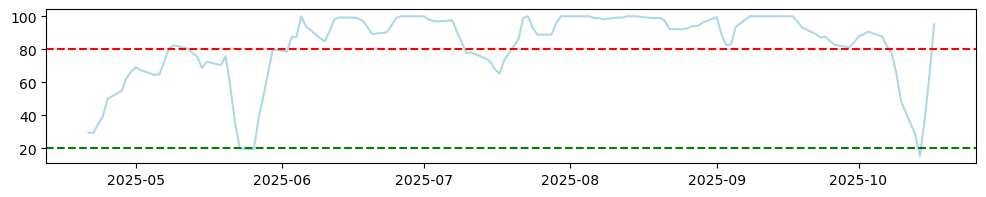

LU1514167995 


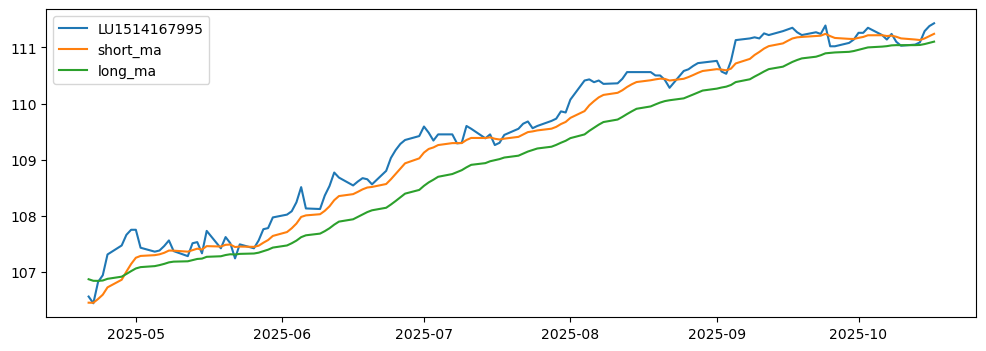

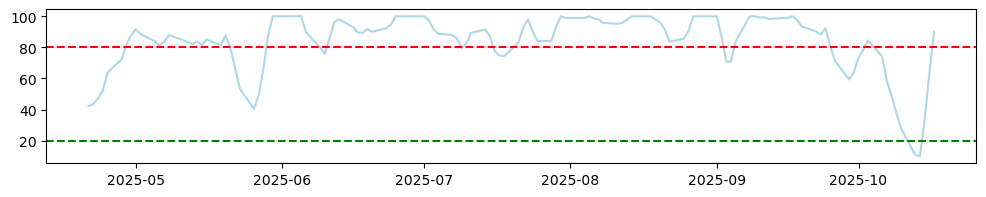

LU0806867908 


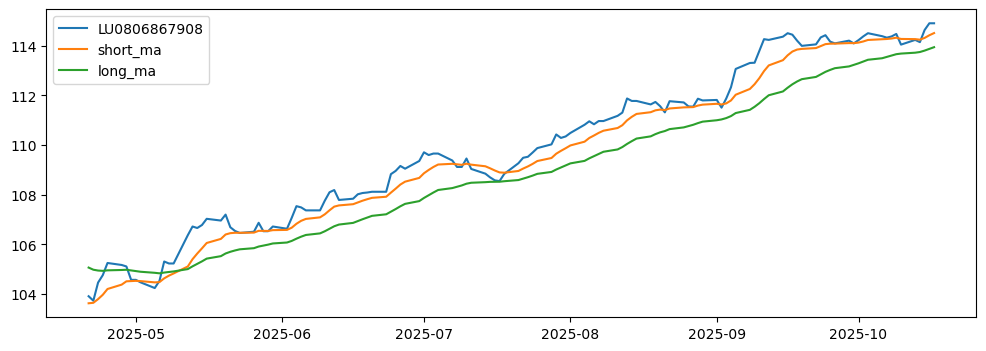

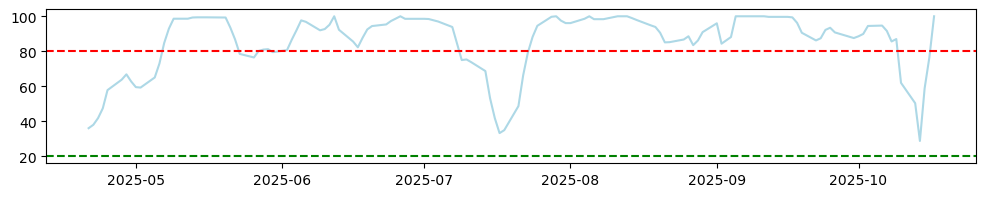

LU1523963418 


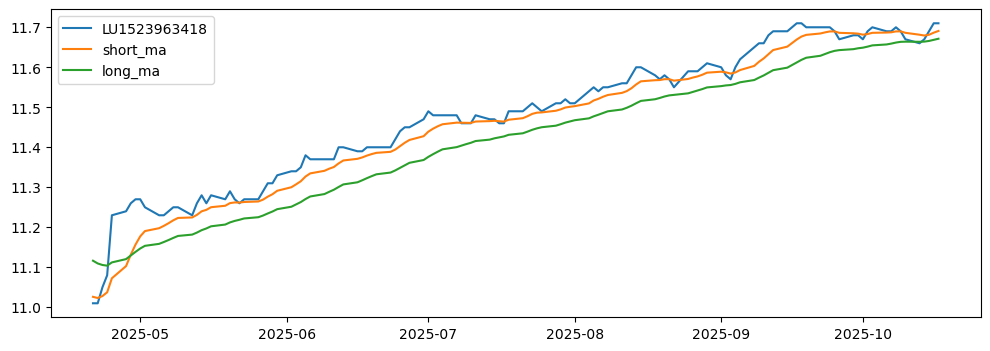

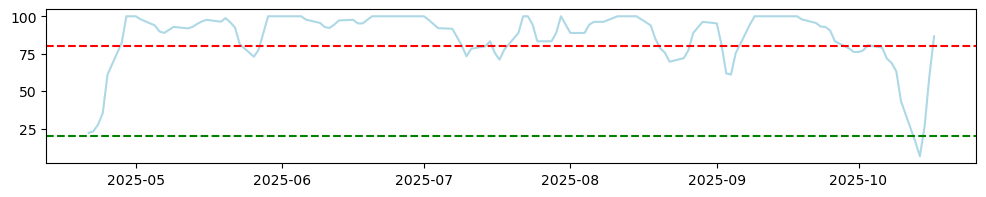

LU1375654800 


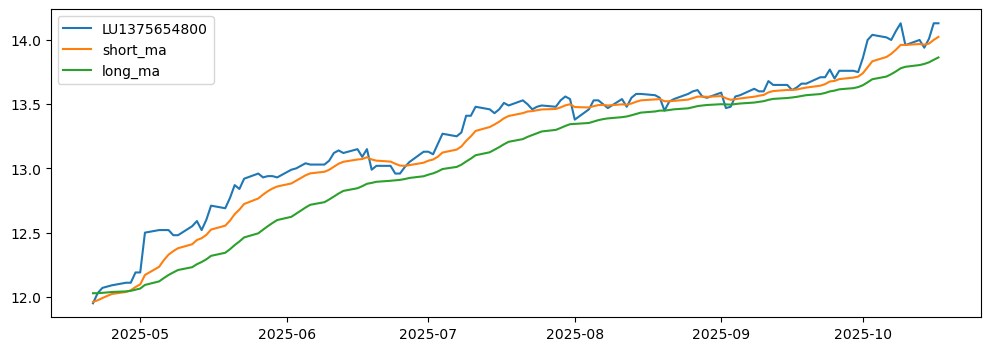

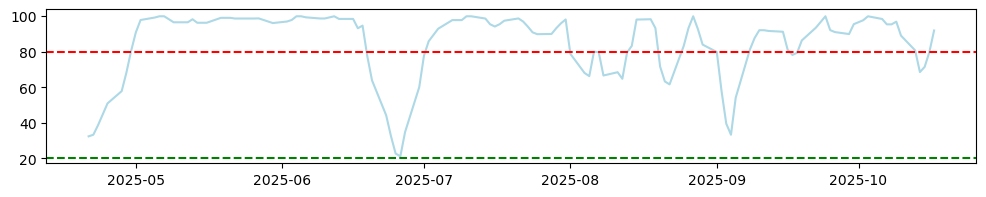

LU1005411738 


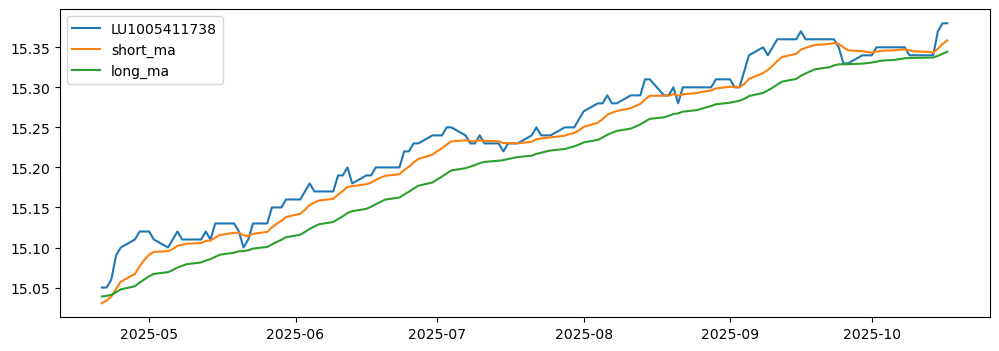

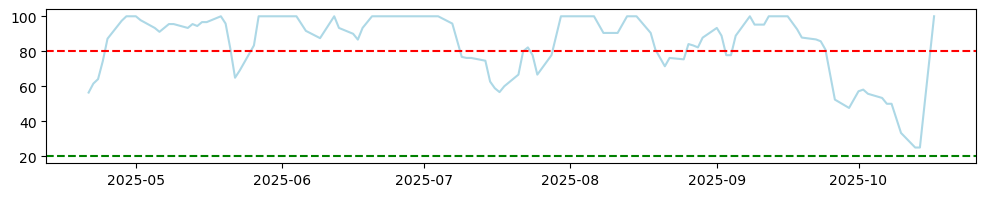

LU1864665275 


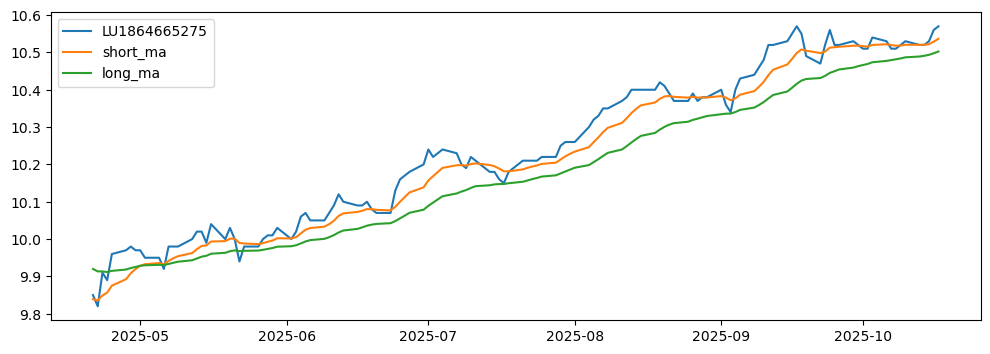

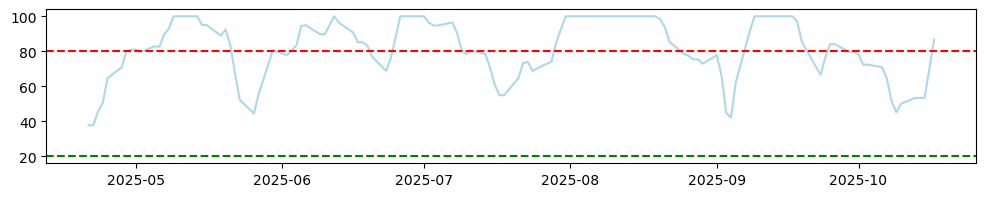

LU1655449863 


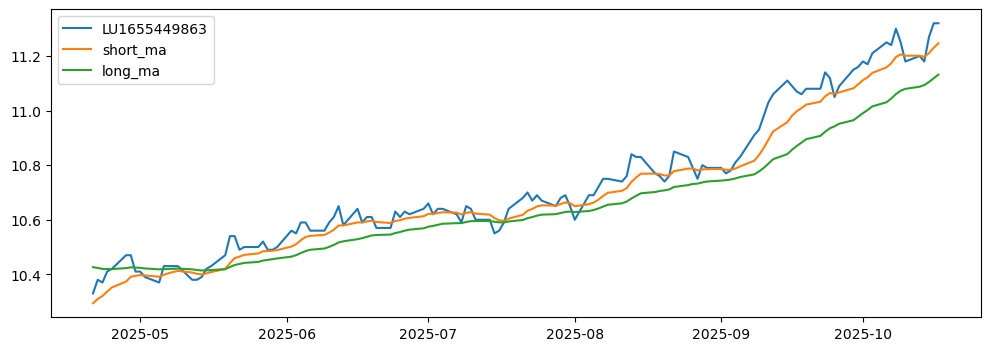

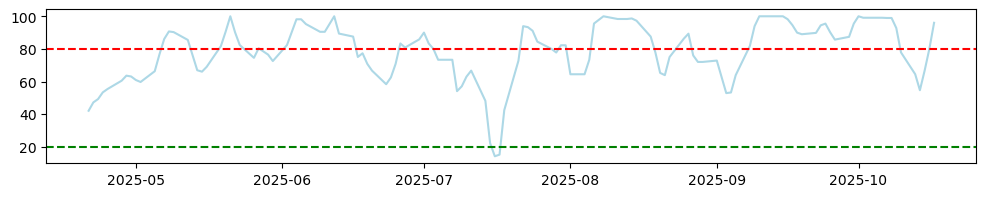

LU0198719832 


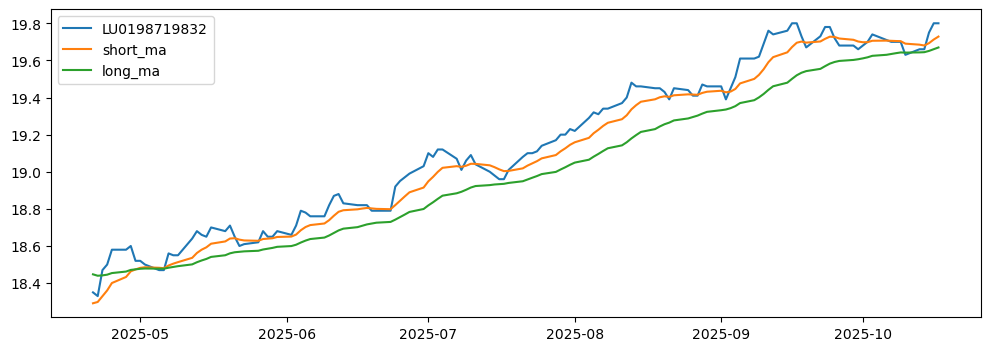

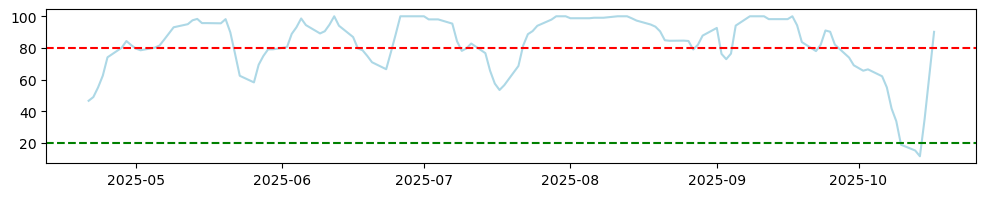

In [9]:

for symb in df_plot.index:
    print(symb,code2name_dict.get(symb,''))
    print_fund_change(symb)
    plot_stochastic_oscillator(symb, period=21, smooth_k=3, smooth_d=3)

In [10]:
def normalize(ds: pd.Series) -> pd.Series:
    # Calculate the IQR to detect high outliers
    Q1 = ds.quantile(0.25)
    Q3 = ds.quantile(0.75)
    IQR = Q3 - Q1

    # Define upper bound for high outliers (outliers above this value will be removed)
    upper_bound = Q3 + 100 * IQR

    # Filter data: keep values below the upper bound
    return ds[ds <= upper_bound]

#df_filter = df_features.index.isin(normalize(df_features['STD']).index) & (df_features['Growth']>0.15) & (df_features['Growth']<0.9)
df_filter = df_features.index.isin(normalize(df_features['STD']).index) & (df_features['Growth']>=0.04) & (df_features['Growth']<0.35)
#df_filter = df_features.index.isin(normalize(df_features['STD']).index) & (df_features['D_Volat']>0.0005)
#df_filter =  (df_features['Growth']>=.2) #& (df_features['Growth']<0.07)

df_plot = df_features[df_filter].sort_values(by=['PricePosition', 'Racio2'], ascending=[False, False]).head(15)
df_plot

,Growth,STD,Racio,D_Volat,Racio2,PricePosition,Oversold Exit,Overbought Entry,Amount EUR
LU2034326152,0.329788,0.002181,137.425321,0.000881,152.041894,1.0,False,False,NaN
LU1897613763,0.279424,0.002168,115.040834,0.000970,121.416117,1.0,False,False,NaN
LU0107088931,0.336295,0.002262,135.402866,0.001584,112.798415,1.0,False,False,NaN
IE0002F6BEM4,0.219302,0.002338,80.959663,0.000797,96.282370,1.0,False,False,NaN
LU1005537912,0.137655,0.001190,90.468612,0.000586,91.157205,1.0,False,False,NaN
LU1062842700,0.149114,0.001567,76.008817,0.000580,87.343793,1.0,False,False,NaN
LU0806867908,0.213959,0.002500,73.575491,0.001023,80.922079,1.0,False,True,NaN
LU1245470163,0.182699,0.001896,80.549390,0.000989,78.853238,1.0,False,False,NaN
IE00BBPRD471,0.255688,0.003350,67.378751,0.001302,75.820006,1.0,False,False,NaN
LU1163203471,0.155931,0.001705,73.851200,0.000827,74.991376,1.0,False,False,NaN


LU2034326152 


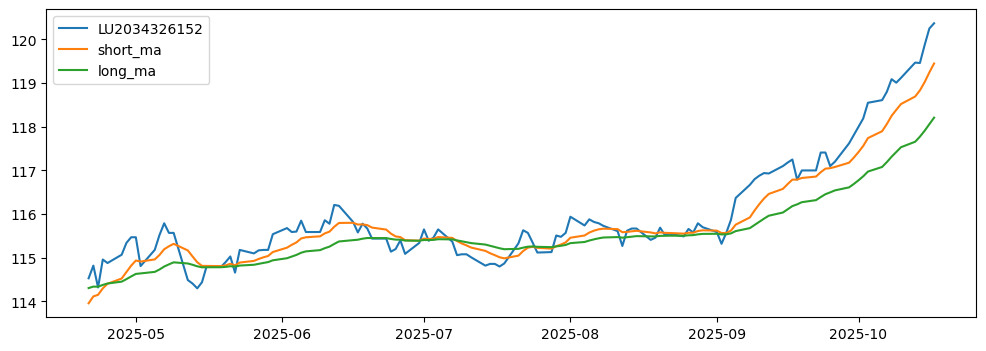

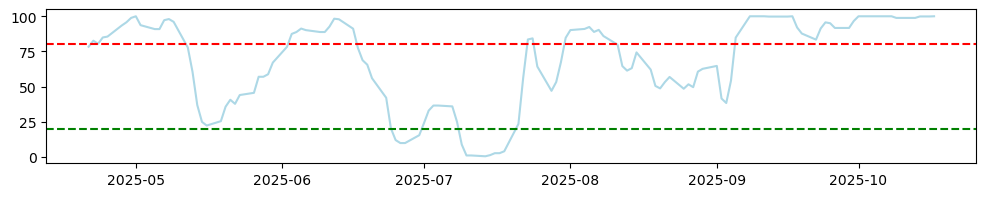

LU1897613763 


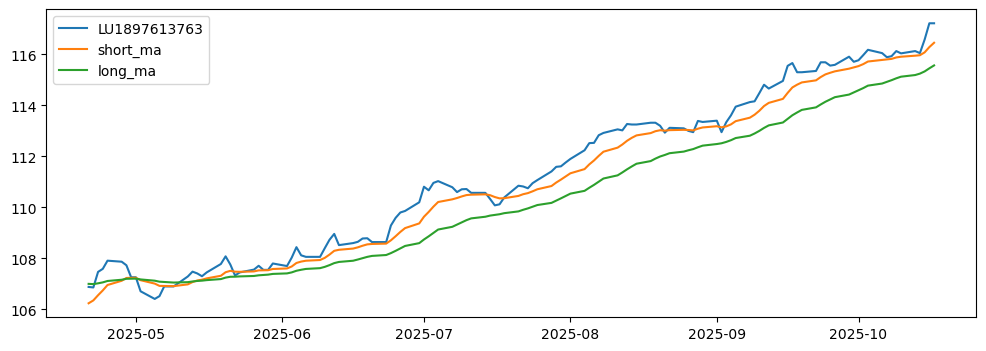

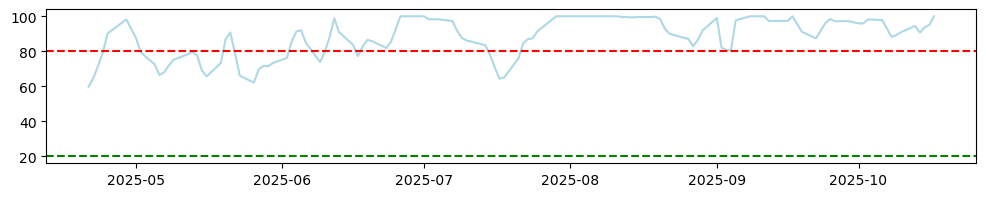

LU0107088931 


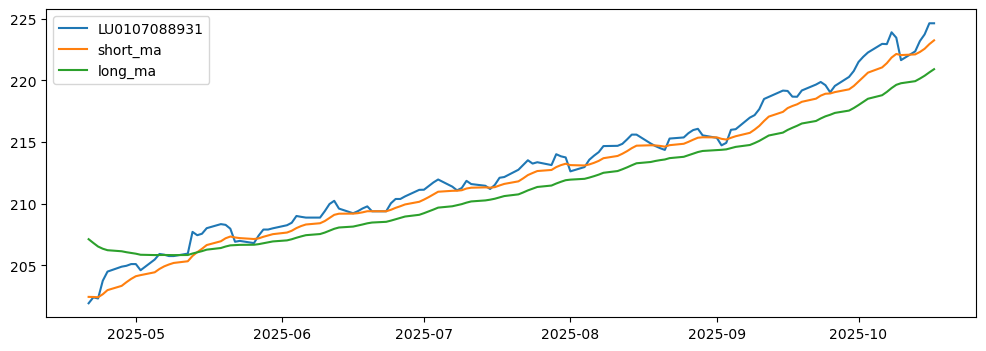

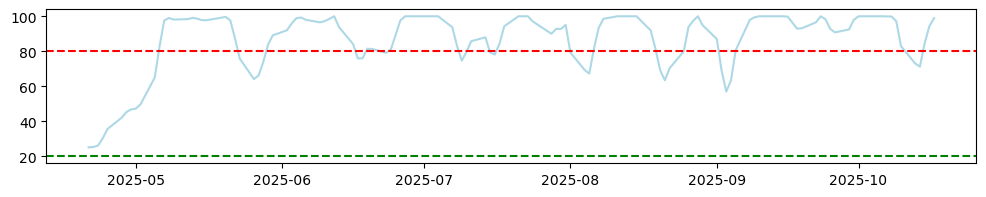

IE0002F6BEM4 


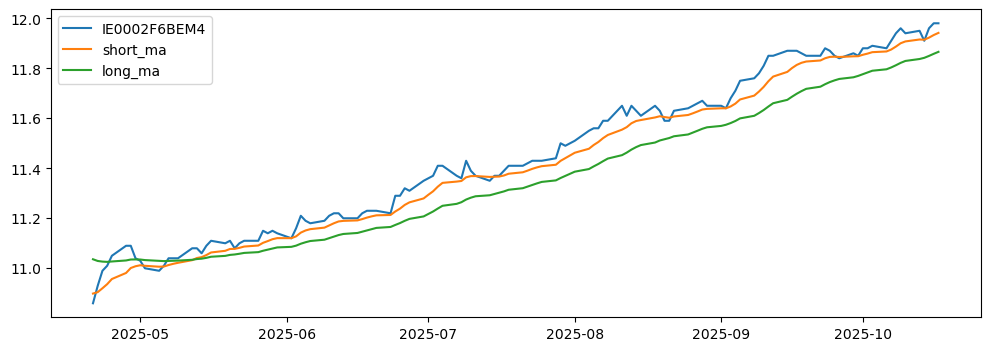

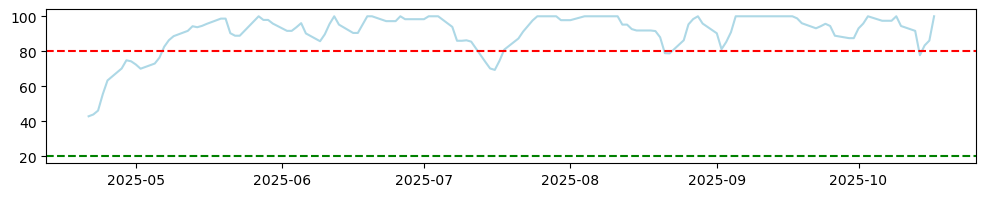

LU1005537912 


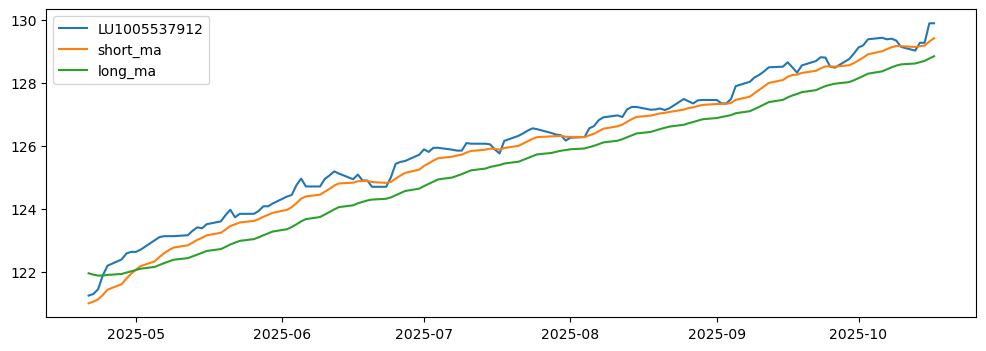

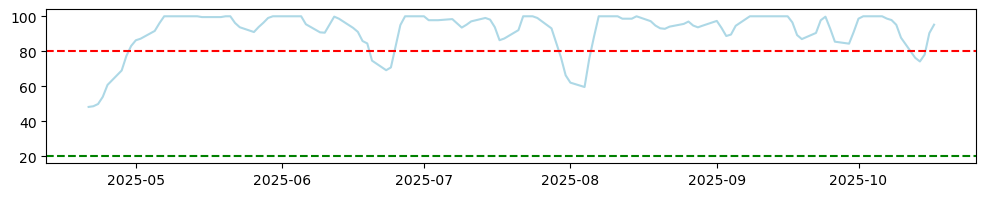

LU1062842700 


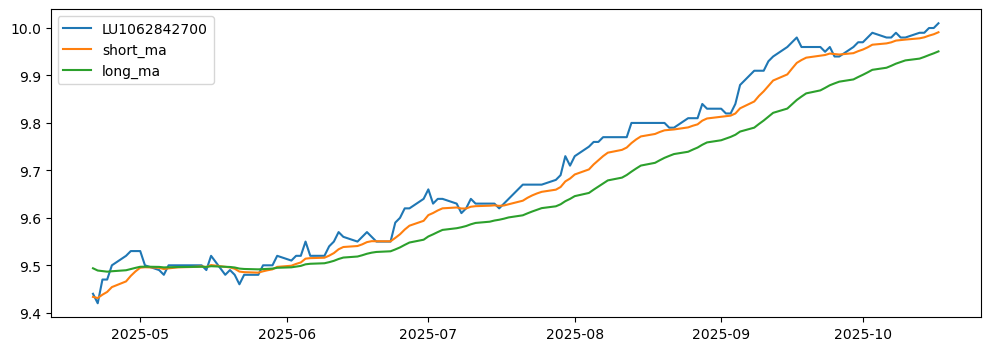

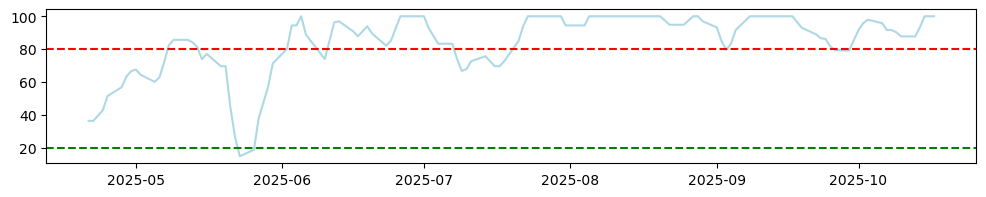

LU0806867908 


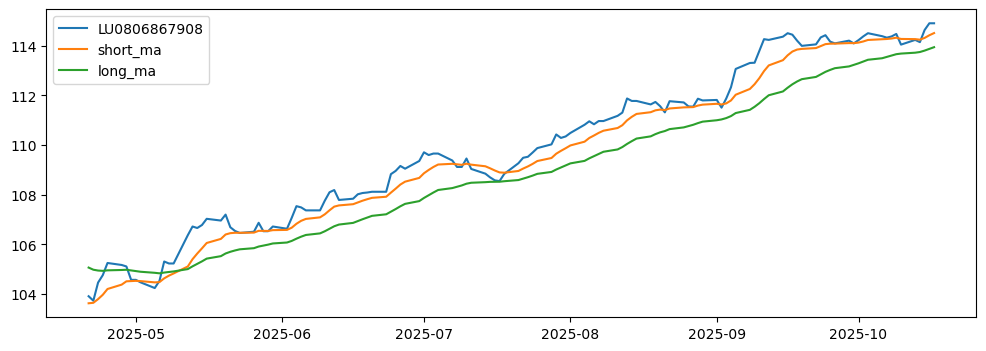

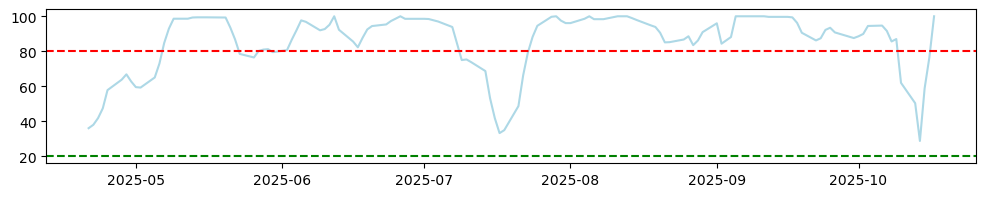

LU1245470163 


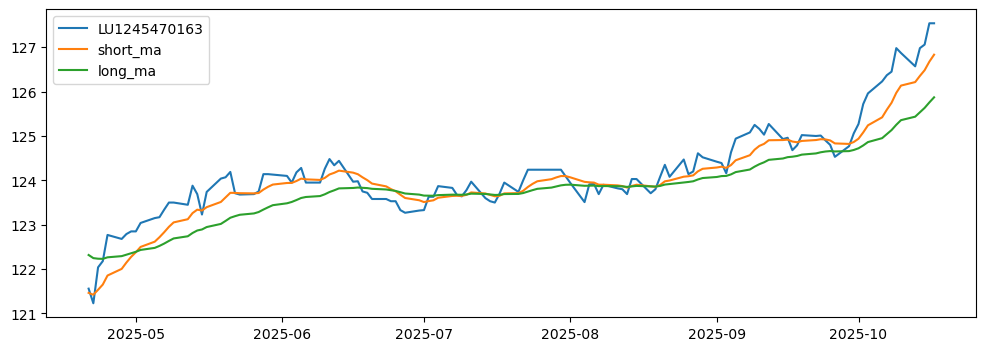

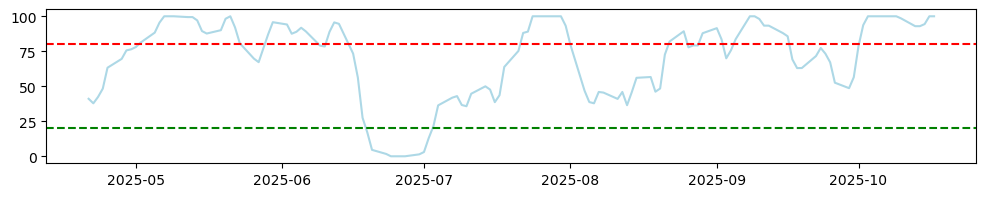

IE00BBPRD471 


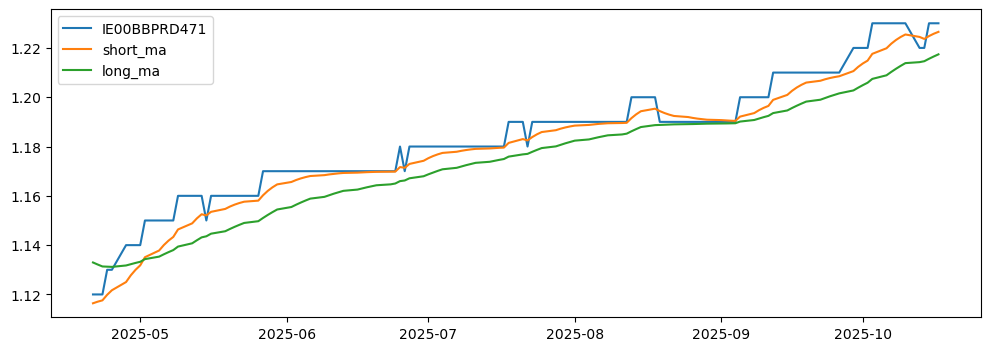

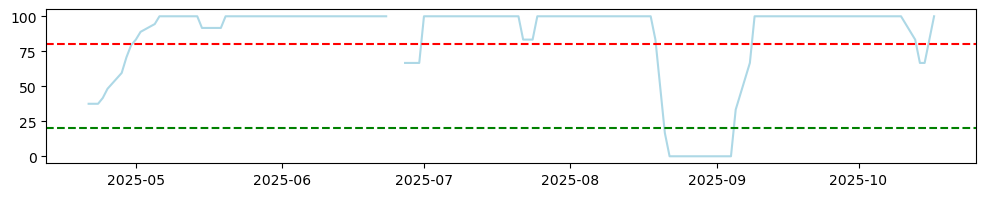

LU1163203471 


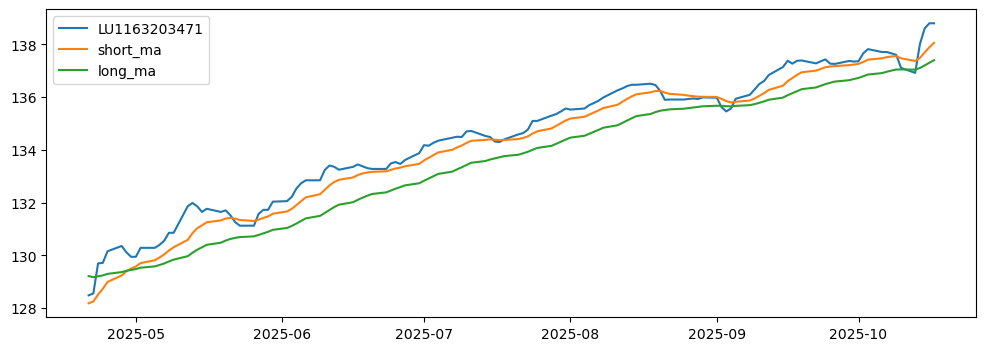

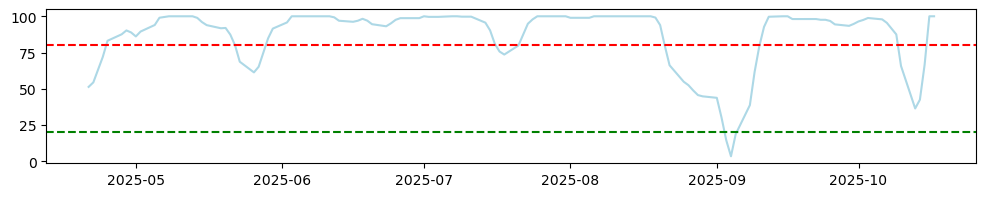

LU0155179483 


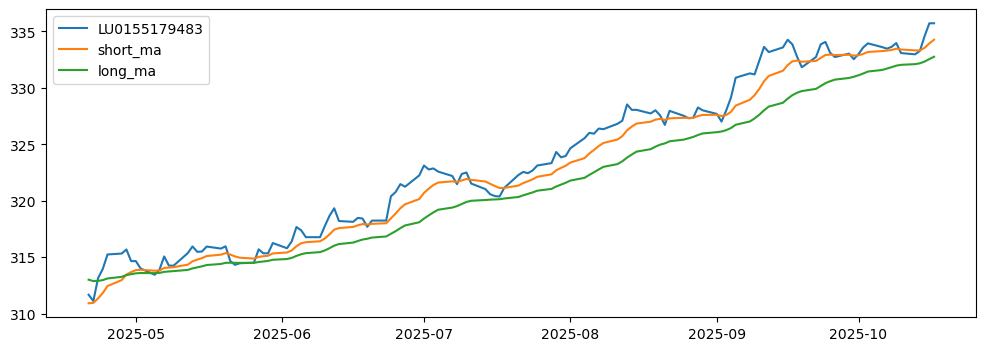

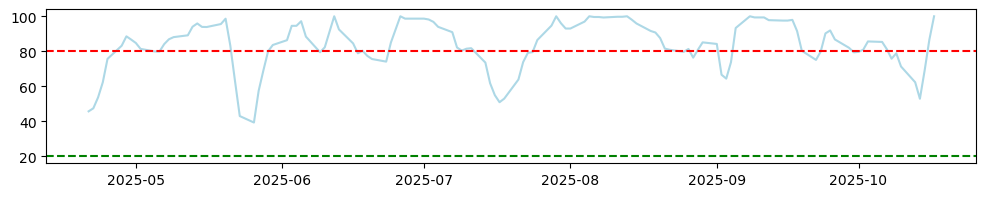

LU1245470759 


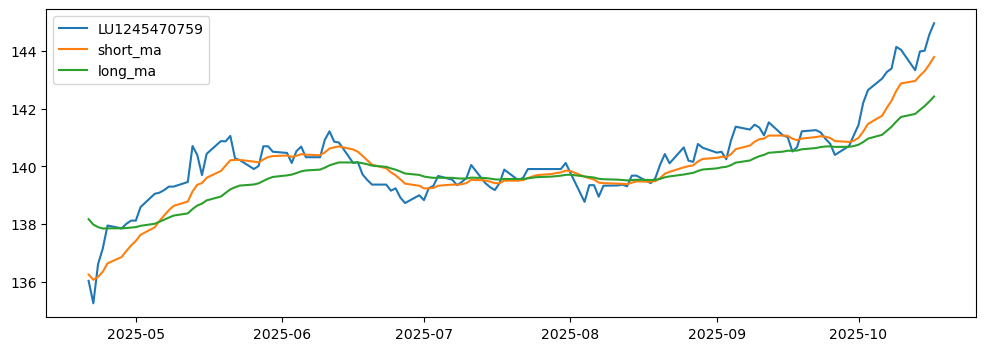

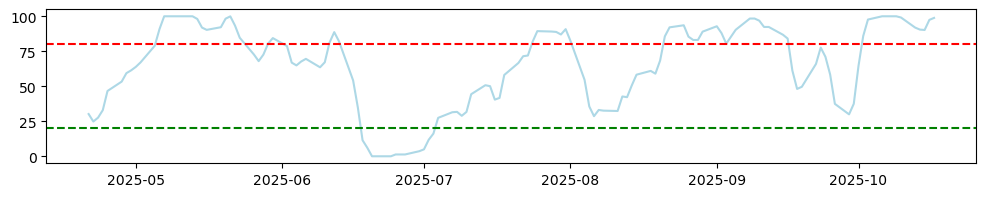

LU0562246966 


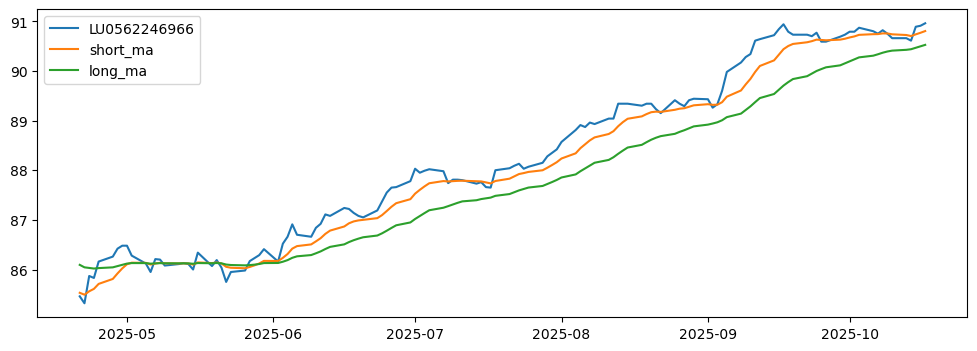

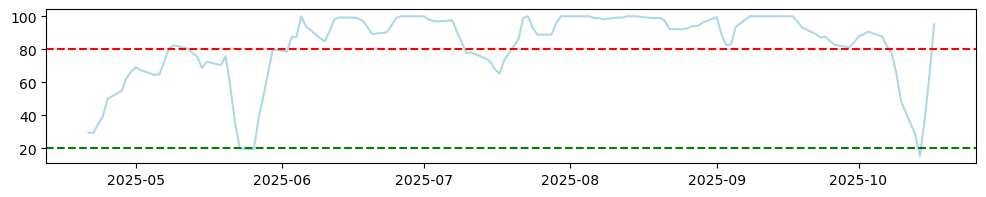

V20A.AS 


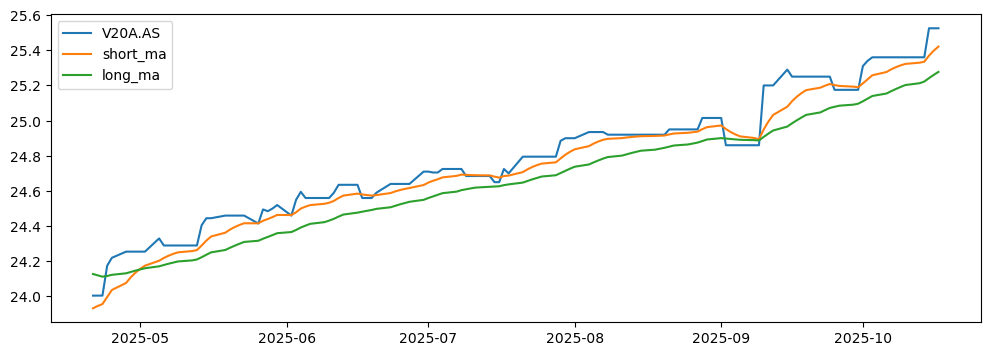

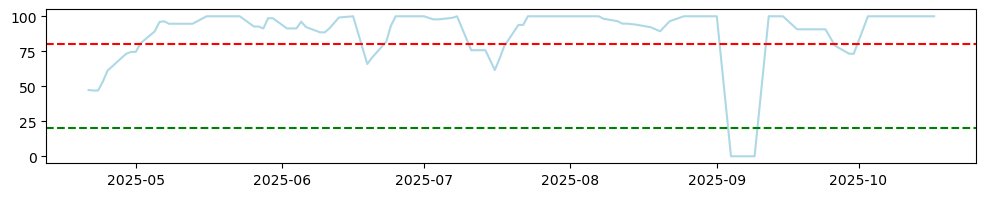

LU0217723054 


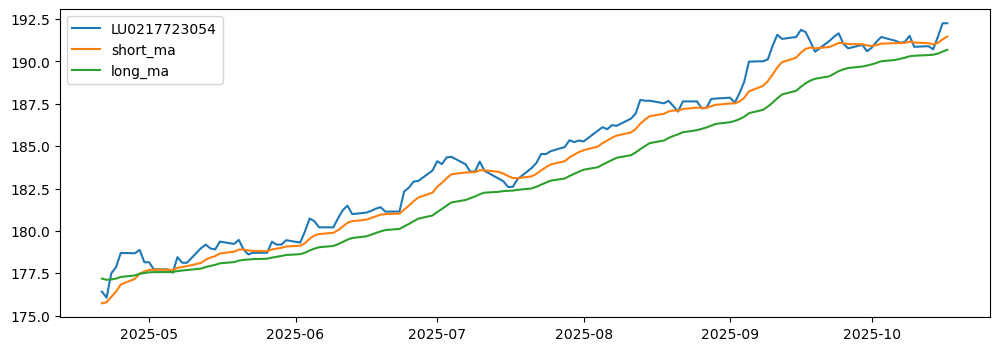

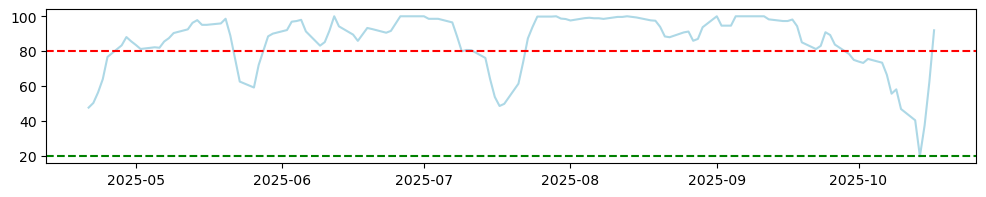

In [11]:

for symb in df_plot.index:
    print(symb,code2name_dict.get(symb,''))
    print_fund_change(symb)
    plot_stochastic_oscillator(symb, period=21, smooth_k=3, smooth_d=3)

In [12]:
df_filter = df_features.index.isin(normalize(df_features['STD']).index) & (df_features['STD']>0.005)

df_plot = df_features[df_filter].sort_values(by='Racio2',ascending=False).head(15)
df_plot

,Growth,STD,Racio,D_Volat,Racio2,PricePosition,Oversold Exit,Overbought Entry,Amount EUR
EDOC,2082.907706,0.175427,11873.164402,0.008678,21608.579734,0.935799,False,False,NaN
LABU,39.642987,0.044423,891.725274,0.015401,1053.175540,0.510464,False,False,NaN
IE00BYVJR916,11.050192,0.018282,602.787531,0.007808,650.189059,1.000000,False,False,NaN
SGLD.AS,3.996890,0.009970,397.880164,0.001989,568.820214,0.994530,False,False,47428.200989
XGDU.DE,3.984916,0.009824,402.580545,0.002070,566.447035,0.993436,False,False,NaN
XAD5.DE,3.967288,0.009874,398.738541,0.002149,555.663258,0.993505,False,False,NaN
4GLD.DE,3.962464,0.009892,397.520764,0.002142,554.759495,0.993242,False,False,NaN
XRH0.L,20.420899,0.040078,508.780828,0.021227,494.135168,1.000000,False,False,NaN
LU1989765471,8.237765,0.018994,432.135066,0.009279,437.148657,1.000000,False,False,NaN
LU1989766289,7.952026,0.019063,415.580778,0.008913,429.522834,1.000000,False,False,NaN


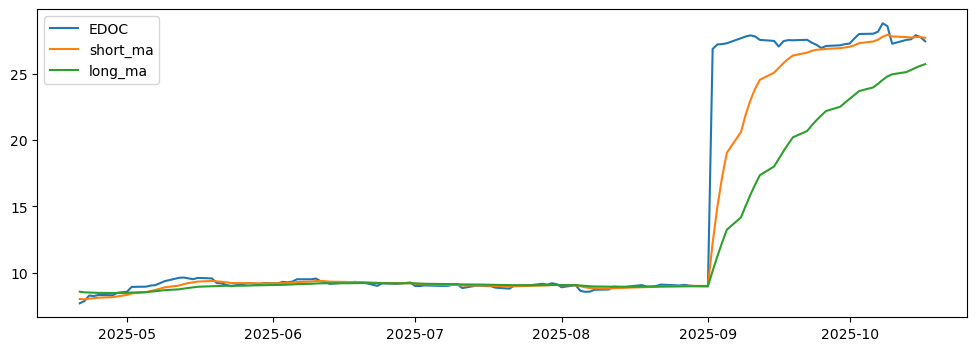

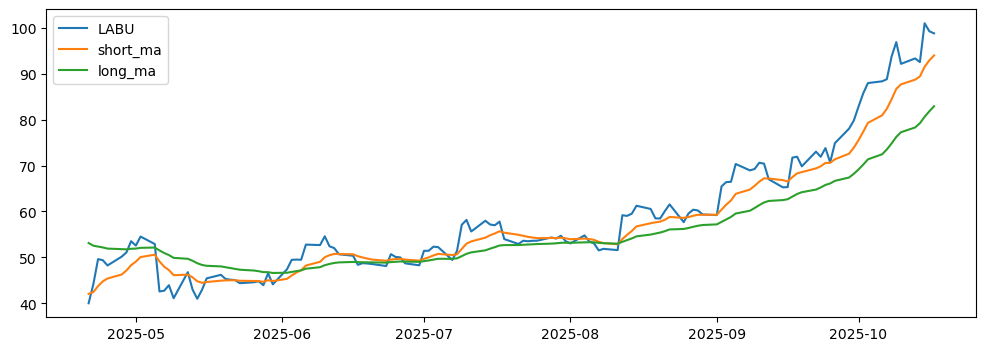

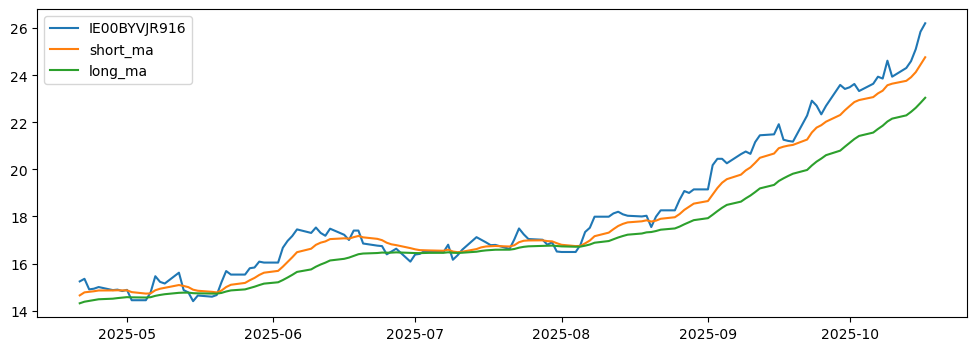

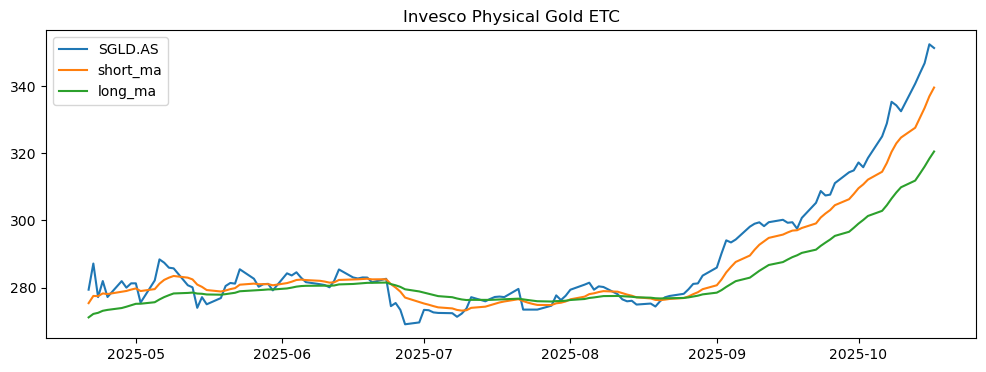

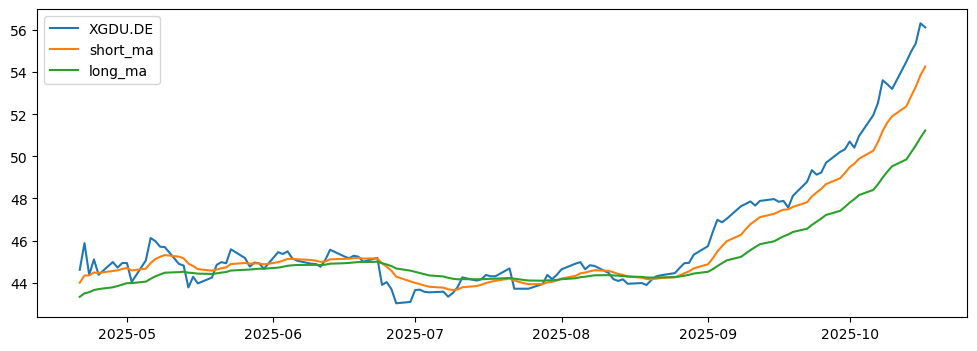

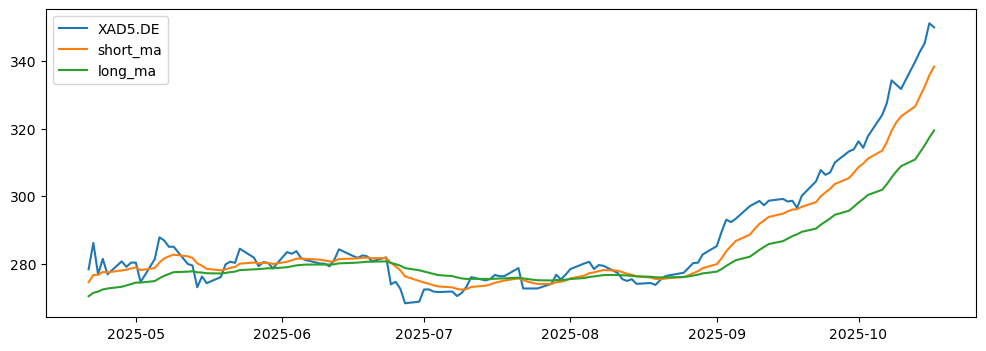

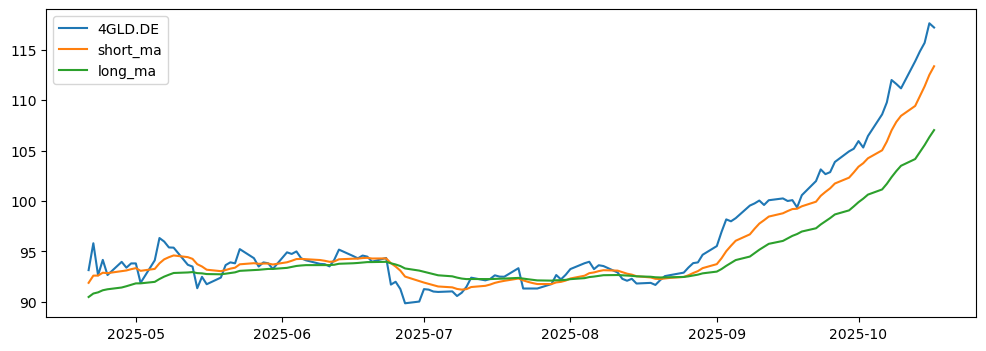

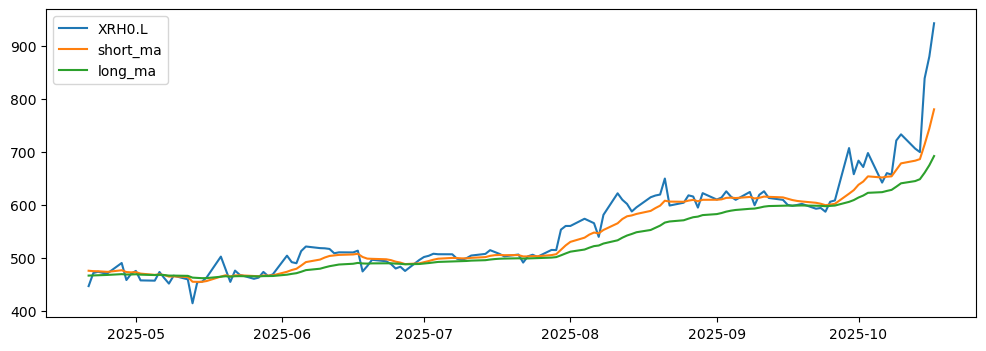

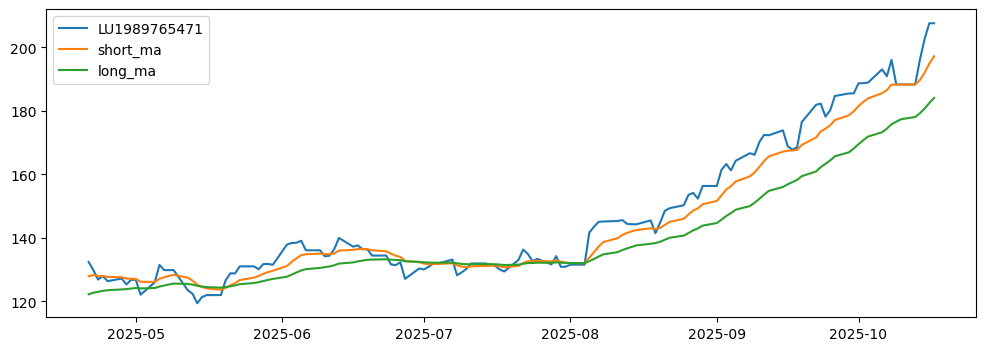

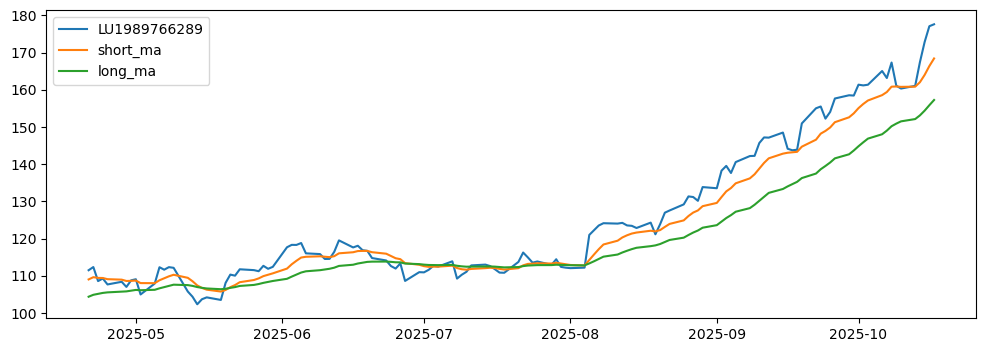

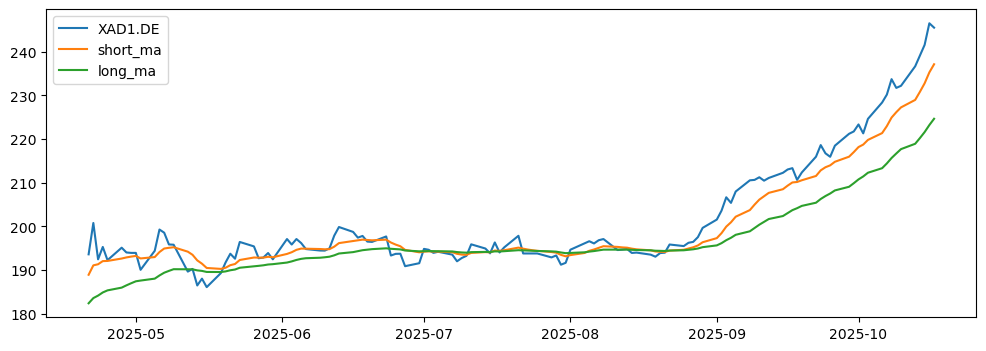

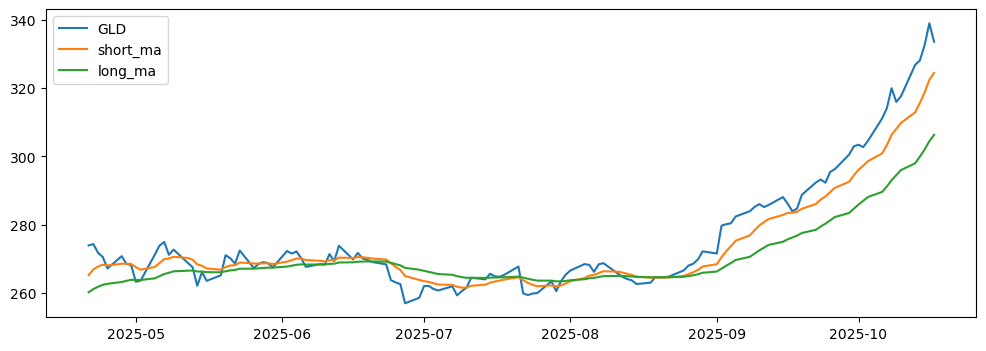

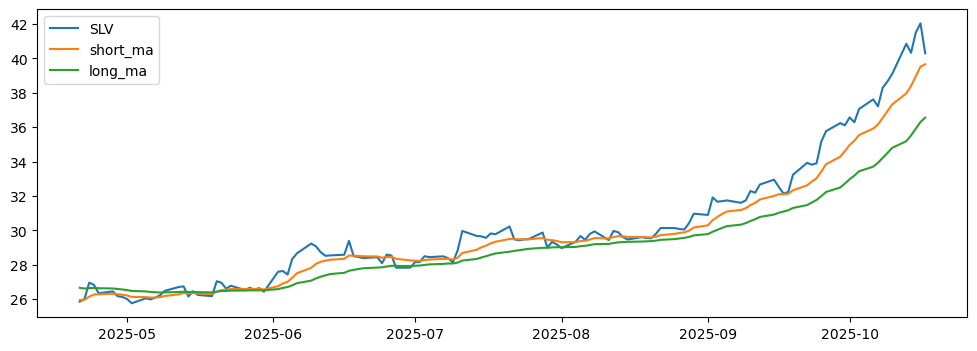

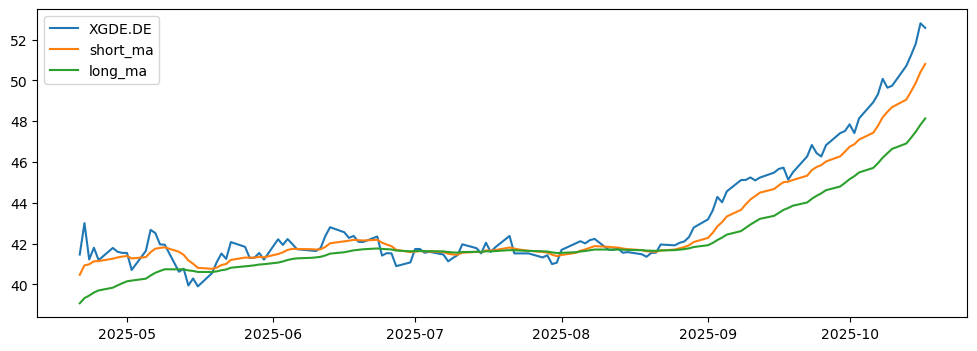

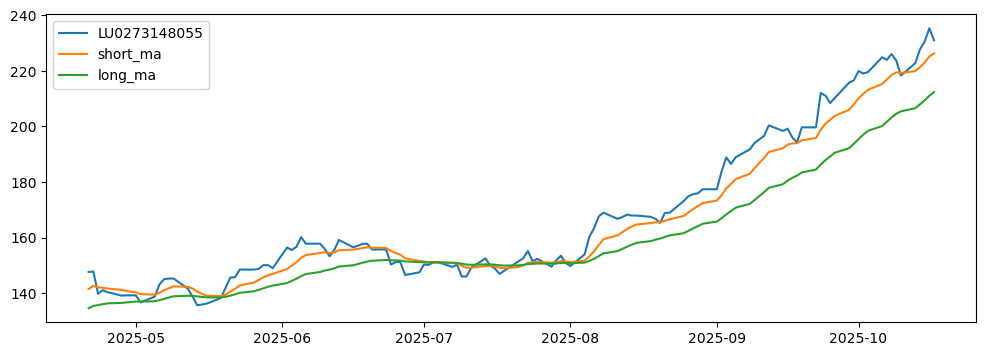

In [13]:

for symb in df_plot.index:
    print_fund_change(symb)

In [14]:
df_filter = df_features.index.isin(['LU1508158513'])
df_plot = df_features[df_filter].sort_values(by='Racio2',ascending=False).head(15)
df_plot


,Growth,STD,Racio,D_Volat,Racio2,PricePosition,Oversold Exit,Overbought Entry,Amount EUR
LU1508158513,-0.153089,0.002557,-71.608924,0.002034,-55.281534,0.844859,False,False,NaN


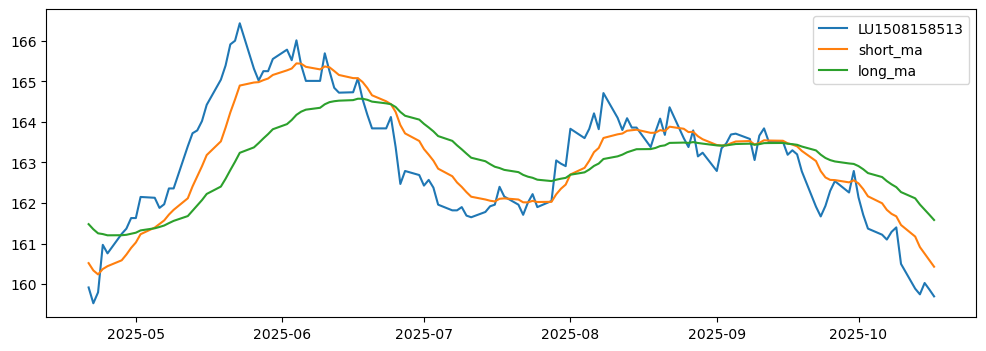

In [15]:
for symb in df_plot.index:
    print_fund_change(symb)

In [16]:
def calculate_correlations(single_series, df_timeseries):
    aligned_series, aligned_df = single_series.align(df_timeseries, join='inner', axis=0)
    
    # Step 2: Convert the aligned Series and DataFrame to NumPy arrays
    series_array = aligned_series.values  # 1D array (single time series)
    df_array = aligned_df.values  # 2D array (list of time series)
    
    # Step 3: Concatenate the single series as the first column with the DataFrame's time series
    combined_data = np.vstack([series_array, df_array.T])  # (n_time_series+1, n_dates) matrix
    
    # Step 4: Compute the correlation matrix using np.corrcoef (works on rows as variables)
    correlation_matrix = np.corrcoef(combined_data)
    
    # Step 5: Extract the correlations between the single series and each time series in the DataFrame
    # The correlation of the first row (single_series) with the remaining rows (df_timeseries)
    single_series_correlations = correlation_matrix[0, 1:]  # First row, excluding self-correlation
    
    # Step 6: Return the result as a Pandas Series with time series column names from df_timeseries
    result = pd.Series(single_series_correlations, index=aligned_df.columns, name='correlation')
    
    return result

def get_correlations():
    #find_top_correlated_pairs(df_quotes)
    corr_list = []

    # Ignore warnings only in this block
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for symb in relevant_etfs:
            df_tmp = pd.concat([df_quotes[symb].shift(1),df_quotes.drop(columns=[symb])],axis=1).apply(lambda x: x/x.shift(-1)).dropna()
            df_corr_tmp = calculate_correlations(df_tmp[symb], df_tmp.drop(columns=[symb])).dropna().reset_index().rename(columns={'index':'ts2'})
            df_corr_tmp = df_corr_tmp[df_corr_tmp['correlation'].apply(lambda x: abs(x)) >= 0.5]
            df_corr_tmp['ts1'] = symb
            corr_list.append(df_corr_tmp[['ts1','ts2','correlation']])

    return pd.concat(corr_list)


In [17]:
def get_negative_correlation():
    #df_corr = df_quotes.corr().reset_index().melt(id_vars='index', var_name='ts2', value_name='correlation').rename(columns={'index': 'ts1'})
    correlation_matrix = np.corrcoef(df_quotes.values, rowvar=False)
    df_corr = pd.DataFrame(correlation_matrix, index=df_quotes.columns, columns=df_quotes.columns).reset_index().melt(id_vars='index', var_name='ts2', value_name='correlation')
    df_corr = df_corr.rename(columns={'index': 'ts1'})
    grow = df_quotes.apply(lambda x: x.iloc[0]/x.loc[get_quote_date(days_ago=365//2)]-1)
    grow = grow[grow>0.015]
    filt = (df_corr['ts1']<df_corr['ts2']) & (df_corr['correlation']<-0.2) & df_corr['ts1'].isin(grow.index) & df_corr['ts2'].isin(grow.index)
    return df_corr[filt].dropna()

df_corr = get_negative_correlation().sort_values(by='correlation')
df_corr

,ts1,ts2,correlation
7108985,LU0366773173,LU1055714965,-0.935862
10439864,LU0566417696,SC0Q.DE,-0.925034
7467769,IE00BLP5S353,LU0366773173,-0.923638
608316,LU0566417696,LU2155809036,-0.921818
7789899,LU0566417696,LU1176912761,-0.918808
...,...,...,...
6764930,DRN,LU2075271812,-0.200004
5274943,ANGL,LU0057074394,-0.200004
8608360,LU0415415636,LU1127391065,-0.200003
2401316,LU0248273137,LU1670707527,-0.200002


OrderedDict([('IYZ', 1.0), ('SCHD', 0.0)])


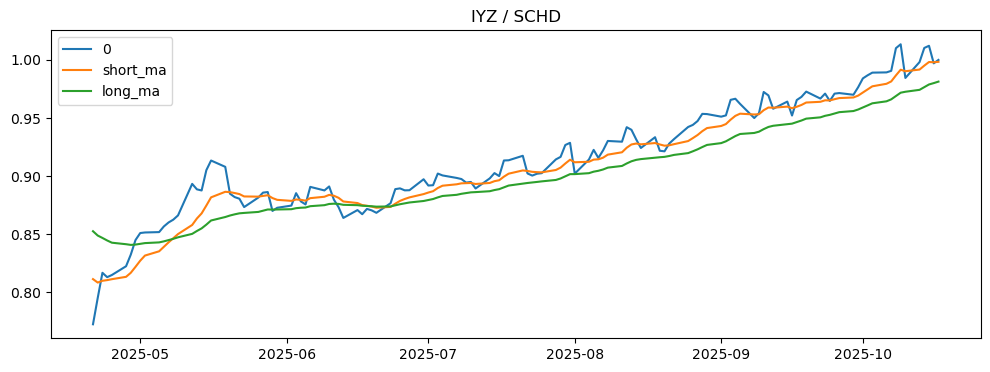

In [18]:
i=27 #17
df_tmp = df_quotes.loc[:get_quote_date(days_ago=365//2)].sort_index()[[df_corr.iloc[i]['ts1'],df_corr.iloc[i]['ts2']]]

mu = mean_historical_return(df_tmp)
S = CovarianceShrinkage(df_tmp).ledoit_wolf()
ef = EfficientFrontier(mu, S)
weights = ef.max_sharpe()
print(weights)
ds_tmp  = weights[df_corr.iloc[i]['ts1']]*df_quotes[df_corr.iloc[i]['ts1']]/df_quotes[df_corr.iloc[i]['ts1']].iloc[0] + weights[df_corr.iloc[i]['ts2']]*df_quotes[df_corr.iloc[i]['ts2']]/df_quotes[df_corr.iloc[i]['ts2']].iloc[0]

_, sma, lma,_,_ = change_trend(ds_tmp)
df_tmp = pd.concat([ds_tmp,sma,lma],axis=1)
title = code2name_dict.get(df_corr.iloc[i]['ts1'],df_corr.iloc[i]['ts1']) + " / " + code2name_dict.get(df_corr.iloc[i]['ts2'],df_corr.iloc[i]['ts2'])
df_tmp.iloc[:130].plot(title=title,figsize=(12,4))
plt.show()

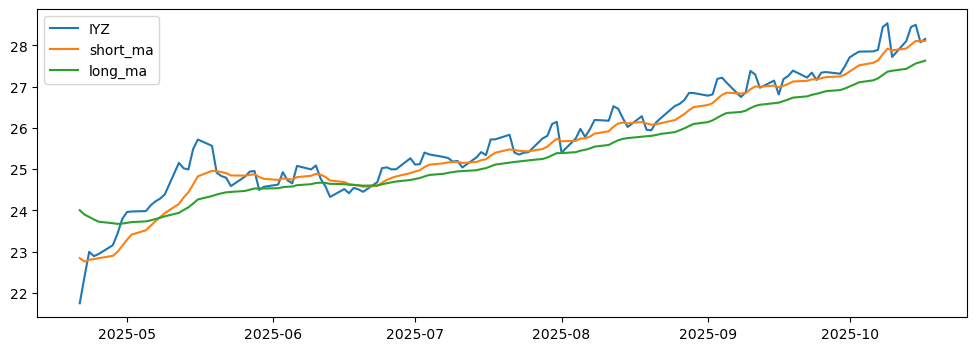

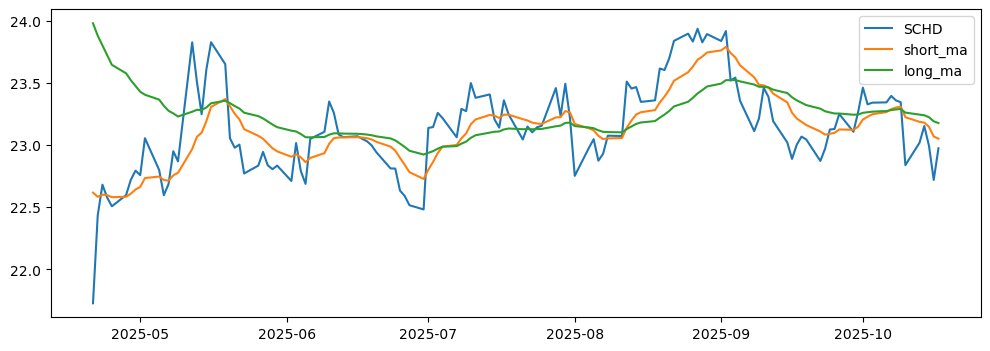

In [19]:
print_fund_change(df_corr.iloc[i]['ts1'])
print_fund_change(df_corr.iloc[i]['ts2'])

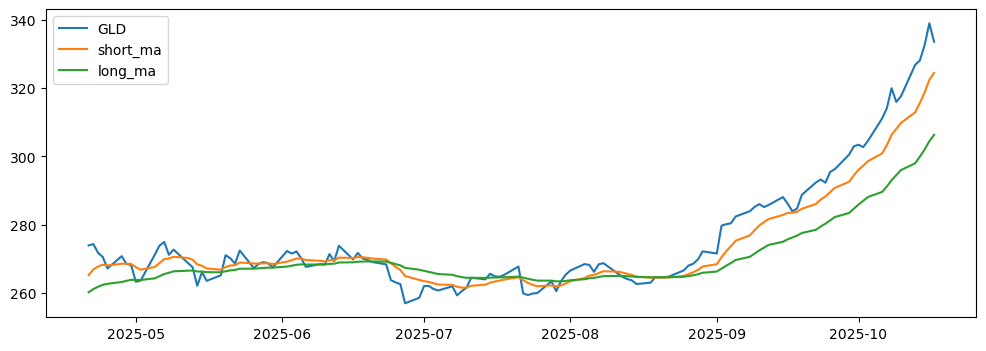

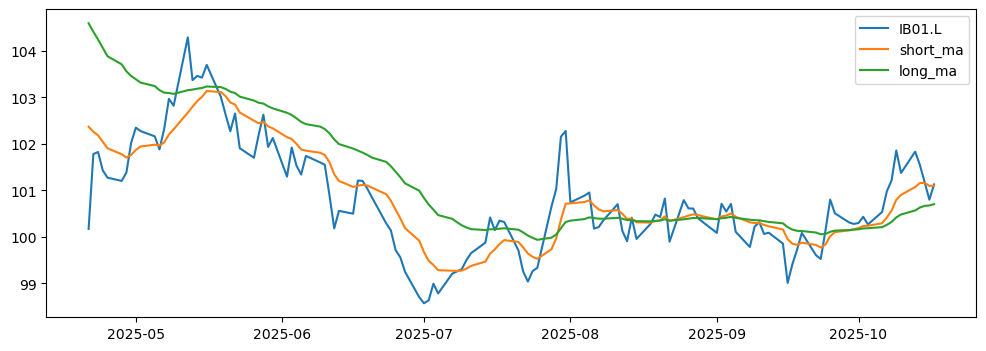

In [20]:
print_fund_change('GLD')
print_fund_change('IB01.L')